USD MS AAI - 590 Capstone Project

Group 3: Manikandan Perumal, Israel Romero Olvera and Darin Verduzco

GitHub: https://github.com/mperumal-usd/capstone_team_3

# Melody Match — Music Similarity using MERT
Melody Match is a deep-learning system for classical music similarity search. 
<br>Given an audio query, it retrieves the most similar pieces from our reference Kaggle Classical 
<br>Music MIDI corpus using semantic embeddings — not rule-based matching.

<br>The system fine-tunes MERT (Music Encoder Representations from Transformers, m-a-p/MERT-v1-95M),
<br>a 95M-parameter audio foundation model pre-trained on large-scale music data. Fine-tuning uses LoRA adapters
<br>and a TripletMarginLoss objective. Embeddings are indexed with FAISS for fast nearest-neighbour retrieval.





Dataset sources: 

Train/Validation: https://www.kaggle.com/datasets/soumikrakshit/classical-music-midi 
<br>Test: https://www.kaggle.com/datasets/blanderbuss/midi-classic-music + 18 files from custom dataset

## <u> Table of Contents:
#### 1. Install and Import Libraries
#### 2. EDA and Data Cleaning
#### 3. Feature Engineering
#### 4. Zero-Shot Model Loading and Training
#### 5. MERT Fine-Tuning with LoRA
#### 6. MERT Fine-Tuning with LoRA + CNN
#### 7. Fine Tuned Model Evaluation on Test Set

# 1. Install and Import Libraries

In [2]:
# ===== System dependencies =====
!apt-get update -qq
!apt-get install -y fluidsynth ffmpeg libsndfile1

# ===== Core Python packages =====
!pip install -q \
numpy pandas scipy tqdm scikit-learn matplotlib seaborn \
pretty_midi librosa soundfile pyfluidsynth \
faiss-cpu \
torch torchvision torchaudio \
transformers peft accelerate \
pillow

In [5]:
# ===== Core / System =====
import os, re, json, sys, shutil, subprocess, tempfile, random
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from collections import Counter, defaultdict
from math import gcd

# ===== Data =====
import numpy as np
import pandas as pd

# ===== Audio / MIDI =====
import pretty_midi, librosa, fluidsynth
import soundfile as sf
from scipy.signal import resample_poly

# ===== Visualization =====
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ===== ML / DL =====
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import faiss

# ===== Transformers =====
from transformers import AutoModel, AutoProcessor
from peft import LoraConfig, get_peft_model, PeftModel

# ===== Utils =====
from tqdm.auto import tqdm
from PIL import Image

# ===== Notebook =====
from IPython.display import Audio
from google.colab import drive

# ===== GPU Check =====
print(torch.cuda.is_available())

In [6]:
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. EDA and Data Cleaning
## Original Notebook: COLAB_Piano_Roll_test.ipynb
### This section contains multiple functions used for EDA first, then the instances of those functions to perform the exploration.
### 2.1 Piano Roll and Similarity Matrix Functions
Define the path to your subfolder.  `AAI590_FinalProject` is directly under `MyDrive`. 

Adjust the `subfolder_path` accordingly.

In [7]:
# Define the path to the subfolder
project_directory = '/content/drive/MyDrive/AAI590_FinalProject'

# Check if the directory exists
if os.path.exists(project_directory):
    print(f"Accessing: {project_directory}")
    # Change the current working directory to the subfolder
    os.chdir(project_directory)
    print(f"Current working directory: {os.getcwd()}")
    print("Contents of the subfolder:")
    # List the contents of the subfolder
    for item in os.listdir(project_directory):
        print(item)
else:
    print(f"The directory '{project_directory}' does not exist. Please check the path and try again.")

Accessing: /content/drive/MyDrive/AAI590_FinalProject
Current working directory: /content/drive/MyDrive/AAI590_FinalProject
Contents of the subfolder:
590-Classical-music-midi
TestingSamples
ChunkSamples
.ipynb_checkpoints


In [8]:
# Setting file system variables
midi_directory = f"{project_directory}/590-Classical-music-midi"
testing_directory = f"{project_directory}/TestingSamples"
chunks_directory = f"{project_directory}/ChunkSamples"

print("Project directory:", project_directory)
print("MIDI directory:", midi_directory)
print("Exists:", Path(midi_directory).exists())
print("Chunks directory:", chunks_directory)

Project directory: /content/drive/MyDrive/AAI590_FinalProject
MIDI directory: /content/drive/MyDrive/AAI590_FinalProject/590-Classical-music-midi
Exists: True
Chunks directory: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples


In [9]:
# Function to load midi file
def load_midi_file(
    file_path: str,
    fs: int = 100
) -> tuple[
    pretty_midi.PrettyMIDI | None,
    float | None,
    pretty_midi.TimeSignature | None,
    int
]:
    """
    Loads a MIDI file from the given file path and returns its PrettyMIDI object,
    initial tempo, time signature, and the frames per second (fs) used for piano roll calculation.

    Args:
        file_path (str): The path to the MIDI file.
        fs (int): Frames per second to use for piano roll calculation (default: 100).

    Returns:
        tuple[pretty_midi.PrettyMIDI | None, float | None, pretty_midi.TimeSignature | None, int]:
            A tuple containing:
            - pretty_midi.PrettyMIDI object if successful, None otherwise.
            - Initial tempo of the MIDI file (float) if successful, None otherwise.
            - Initial time signature of the MIDI file (pretty_midi.TimeSignature) if successful, None otherwise.
            - Frames per second (fs) used for piano roll.
    """
    if not os.path.exists(file_path):
        print(f"Error: File not found at {file_path}")
        return None, None, None, fs # Return None for midi_data, tempo, and time_signature, but fs value

    try:
        midi_data = pretty_midi.PrettyMIDI(file_path)
        print(f"Successfully loaded MIDI file: {file_path}")

        tempo_times, tempos = midi_data.get_tempo_changes()
        print(f"Tempo changes loaded correctly")

        if(tempos.size > 0):
            print(f"Initial tempo: {tempos[0]}")
            initial_tempo = tempos[0]
        else:
            print(f"No tempo changes found in the MIDI file")
            initial_tempo = 120.0 # Default to 120 BPM if no tempo changes explicitly set
        #initial_tempo = tempos[0] if tempos else 120.0 # Default to 120 BPM if no tempo changes explicitly set
        print(f"Initial tempo selected correctly")

        initial_time_signature = midi_data.time_signature_changes[0] if midi_data.time_signature_changes else None
        print(f"Initial time signature loaded correctly")

        return midi_data, initial_tempo, initial_time_signature, fs
    except Exception as e:
        print(f"Error loading MIDI file {file_path}: {e}")
        return None, None, None, fs # Return None for midi_data, tempo, and time_signature, but fs value

In [10]:
# Function for midi split
def split_midi_by_measure(pm_data: pretty_midi.PrettyMIDI) -> list[pretty_midi.PrettyMIDI]:
    """
    Splits a PrettyMIDI object into a list of PrettyMIDI objects, one for each measure.
    Notes are adjusted to have start/end times relative to the beginning of their measure.

    Args:
        pm_data (pretty_midi.PrettyMIDI): The PrettyMIDI object to split.

    Returns:
        list[pretty_midi.PrettyMIDI]: A list of PrettyMIDI objects, each representing a measure.
    """
    measures = []
    downbeats = pm_data.get_downbeats()

    if not downbeats:
        print("No downbeats found. Returning original MIDI as a single measure.")
        return [pm_data]

    # Add an implicit end boundary if the last downbeat is not the very end of the piece
    end_time = (
        max(
            note.end
            for instrument in pm_data.instruments
            for note in instrument.notes
        )
        if pm_data.instruments
        else 0
    )
    measure_boundaries = list(downbeats)
    if measure_boundaries[-1] < end_time:
        measure_boundaries.append(end_time)

    for i in range(len(measure_boundaries) - 1):
        measure_start_time = measure_boundaries[i]
        measure_end_time = measure_boundaries[i+1]

        # Create a new PrettyMIDI object for this measure
        measure_pm = pretty_midi.PrettyMIDI(resolution=pm_data.resolution)

        # Copy time signature and tempo map for the current measure if they fall within its bounds
        # This simplified approach assumes the first relevant time signature/tempo is representative.
        # A more robust solution would track changes throughout the measure.
        for ts in pm_data.time_signature_changes:
            if measure_start_time <= ts.time < measure_end_time:
                measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(ts.numerator, ts.denominator, 0)) # Set time to 0 for relative measure start
                break # Assuming one time signature per measure for simplicity
        if not measure_pm.time_signature_changes and pm_data.time_signature_changes:
             # If no explicit TS found in bounds, use the last one before measure start
             relevant_ts = [ts for ts in pm_data.time_signature_changes if ts.time <= measure_start_time]
             if relevant_ts:
                 last_ts = relevant_ts[-1]
                 measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(last_ts.numerator, last_ts.denominator, 0))
             else:
                measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(4, 4, 0)) # Default if nothing found
        elif not measure_pm.time_signature_changes:
            measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(4, 4, 0)) # Default if no TS in original MIDI

        # Iterate through instruments and notes
        for original_instrument in pm_data.instruments:
            new_instrument = pretty_midi.Instrument(program=original_instrument.program,
                                                    is_drum=original_instrument.is_drum,
                                                    name=original_instrument.name)
            for note in original_instrument.notes:
                # Check if the note is within the current measure's boundaries
                # A note is considered in the measure if its start time is within the measure,
                # or if it starts before and extends into the measure.
                if (measure_start_time <= note.start < measure_end_time) or \
                   (note.start < measure_start_time and note.end > measure_start_time):

                    # Adjust note start and end times relative to the measure's start
                    relative_start = max(0.0, note.start - measure_start_time)
                    relative_end = note.end - measure_start_time

                    # Ensure the note doesn't extend beyond the measure's relative end
                    relative_end = min(relative_end, measure_end_time - measure_start_time)

                    # Only add note if it has a positive duration within the measure
                    if relative_end > relative_start:
                        new_note = pretty_midi.Note(
                            velocity=note.velocity,
                            pitch=note.pitch,
                            start=relative_start,
                            end=relative_end
                        )
                        new_instrument.notes.append(new_note)
            if new_instrument.notes:
                measure_pm.instruments.append(new_instrument)

        measures.append(measure_pm)

    return measures

In [24]:
# Convert MIDI to audio wave file (required for MERT)
def midi_file_to_audio(midi_path, sr=24000):
    midi = pretty_midi.PrettyMIDI(midi_path)
    audio = midi.fluidsynth(fs=sr)
    return audio, sr
def midi_data_to_audio(midi_data, sr=24000):
    audio = midi_data.fluidsynth(fs=sr)
    return audio, sr
def save_audio(audio, sr, output_path):
    # Save the audio content to a WAV file
    sf.write(output_path, audio, sr)
    print(f"Audio saved to: {output_path}")
def create_midi_sequence_from_notes(notes, offset=0):
    """
    Creates a PrettyMIDI object from a list of note tuples.
    Each note tuple is expected to be (pitch, start, end, duration).
    """
    midi_sequence = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)  # Selecting Piano
    for note_array in notes:
        pitch, start, end, duration = note_array
        # Explicitly cast pitch to int, as numpy array might have cast it to float
        new_note = pretty_midi.Note(
            velocity=127,
            pitch=int(pitch),  # Ensure pitch is an integer
            start=start - offset,
            end=end - offset
        )
        instrument.notes.append(new_note)
    midi_sequence.instruments.append(instrument)
    return midi_sequence
def midi_to_note_sequence(midi_path):
    midi = pretty_midi.PrettyMIDI(midi_path)
    notes = []
    for instrument in midi.instruments:
        for note in instrument.notes:
            notes.append([
                int(note.pitch),  # Pitch must be int
                note.start,       # Keep as float for precise timing
                note.end,         # Keep as float for precise timing
                note.end - note.start # Duration (float)
            ])
    notes = sorted(notes, key=lambda x: x[1])
    return np.array(notes)
def chunk_notes(notes, chunk_size=32):
    chunks = []
    # Breaking into chunks with 50% overlap, so i will increment by chunk_size/2 each iteration
    chunk_iteration = int(chunk_size/2)
    for i in range(0, len(notes), chunk_iteration):
        chunk = notes[i:i+chunk_size]
        if len(chunk) == chunk_size:
            chunks.append(chunk)
    return chunks
def embed_chunks(chunks):
    embeddings = []
    for chunk in chunks:
        # simple numeric representation for MERT placeholder
        vec = chunk.flatten()
        embeddings.append(vec)
    return embeddings
def get_first_note_start_in_chunk(chunk):
    # Get all note start times
    note_start_times = [note[1] for note in chunk]
    # Get the first note time
    first_note_time = min(note_start_times)
    return first_note_time
def chunks_to_audio(chunks, output_wav_path):
    i = 1
    for chunk in chunks:
        tmp_output_path = output_wav_path.replace('.wav', f'_chunk_{i}.wav')
        #print(f'Preparing file {tmp_output_path}...')
        first_note_time = get_first_note_start_in_chunk(chunk)
        #print(f'First note time in chunk: {first_note_time}')
        midi_sequence = create_midi_sequence_from_notes(chunk, first_note_time)
        #print(f'Midi sequence for file {tmp_output_path}:')
        #print(midi_sequence)
        audio, sr = midi_data_to_audio(midi_sequence)
        save_audio(audio, sr, tmp_output_path)
        i += 1
    return i - 1
def create_chunks_from_midi(midi_path, sr=24000, chunk_size=32, audio_path=''):
    if(audio_path == ''):
        audio_path = midi_path
    wav_path = audio_path.replace('.mid', '.wav')
    notes = midi_to_note_sequence(midi_path)
    #print('Notes:')
    #print(notes)
    chunks = chunk_notes(notes, chunk_size)
    #print('Chunks')
    #print(chunks)
    chunk_file_count = chunks_to_audio(chunks, wav_path)
    print(f'Created {chunk_file_count} chunks from {midi_path}')

In [12]:
# Function to find first note
def get_frame_first_note(midi_content, fs):
  #Get all note start times
  note_start_times = [note.start for instrument in midi_content.instruments for note in instrument.notes]
  #Get the first note time
  first_note_time = min(note_start_times)
  #Calculate the frame in which the note shows up
  first_frame = int(first_note_time * fs)
  #Return the first frame
  return first_frame
def midi_to_pianoroll(midi_path):
  # Load MIDI
  midi_data, initial_tempo, initial_time_signature, piano_roll_fs = load_midi_file(midi_path)
  if midi_data is None:
      return None, None
  # Get first frame with a note
  first_active_frame = get_frame_first_note(midi_data, piano_roll_fs)

  # Full piano roll, shape: (128, time)
  piano_roll = midi_data.get_piano_roll(fs=piano_roll_fs)
  piano_roll = piano_roll / 127.0  # Normalize velocity
  piano_roll = piano_roll[:, first_active_frame:]  # Trim leading silence
  piano_roll = piano_roll.T  # Now shape: (time, 128)

  # Clip to valid MIDI range
  piano_roll = piano_roll[:, :128]

  return piano_roll, piano_roll_fs

# Function to plot piano roll    
def plot_piano_roll(midi_path, title="Piano Roll", save_path=None):
  #First we obtain the piano roll based on the path
  piano_roll, fs = midi_to_pianoroll(midi_path)
  time_steps = piano_roll.shape[0] #Getting timesteps
  duration = time_steps / fs #Calculating duration
  time_axis = np.linspace(0, duration, time_steps) #Preparing time axis dimension
  print(f'Time Steps: {time_steps}, Frames per Second: {fs}, Duration: {duration:.2f}s')
  #Next, we plot the Piano Roll
  plt.figure(figsize=(12, 6))
  plt.imshow(piano_roll.T, aspect='auto', origin='lower',
              extent=[0, duration, 0, piano_roll.shape[1]], cmap='gray_r')
  plt.xlabel('Time (s)')
  plt.ylabel('MIDI Note')
  plt.title(title)
  plt.tight_layout()

  if save_path:
      plt.savefig(save_path)
  else:
      plt.show()

### 2.2 - Data Exploration using Piano Roll.

Successfully loaded MIDI file: /content/drive/MyDrive/AAI590_FinalProject/590-Classical-music-midi/beeth/elise.mid
Tempo changes loaded correctly
Initial tempo: 69.17997516438892
Initial tempo selected correctly
Initial time signature loaded correctly
Time Steps: 16473, Frames per Second: 100, Duration: 164.73s


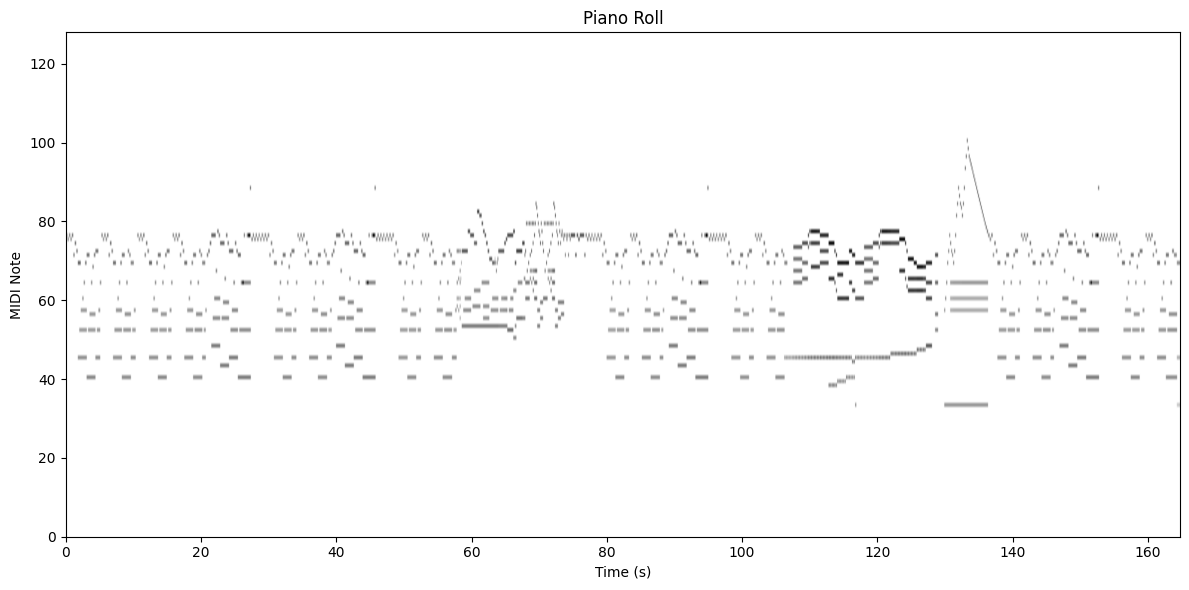

In [14]:
# Set path and plot sample piano roll
sample_path = f'{midi_directory}/beeth/elise.mid'
plot_piano_roll(sample_path)

In [13]:
# Midi path from test dir
example_midi_path = os.path.join(
    esting_directory,
    'MidiOutputs/Beethoven/Fur Elise_Full_K-Amin_T-variable_bothhands.mid'
)

# Call the function and capture the returned values
midi_data_obj, initial_tempo, initial_time_signature, piano_roll_fs = load_midi_file(example_midi_path, fs=100)

# Print the captured parameters
if midi_data_obj:
    print(f"\nMIDI Data Object: {midi_data_obj}")
    print(f"Initial Tempo: {initial_tempo} BPM")
    if initial_time_signature:
        print(f"Initial Time Signature: {initial_time_signature.numerator}/{initial_time_signature.denominator}")
    else:
        print("Initial Time Signature: Not found")
    print(f"Frames Per Second (fs) for Piano Roll: {piano_roll_fs}")
else:
    print("Failed to load MIDI file.")

Successfully loaded MIDI file: /content/drive/MyDrive/AAI590_FinalProject/TestingSamples/MidiOutputs/Beethoven/Fur Elise_Full_K-Amin_T-variable_bothhands.mid
Tempo changes loaded correctly
Initial tempo: 75.0
Initial tempo selected correctly
Initial time signature loaded correctly

MIDI Data Object: <pretty_midi.pretty_midi.PrettyMIDI object at 0x7c8914c9b530>
Initial Tempo: 75.0 BPM
Initial Time Signature: 3/8
Frames Per Second (fs) for Piano Roll: 100


/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Successfully loaded MIDI file: /content/drive/MyDrive/AAI590_FinalProject/TestingSamples/MidiOutputs/Beethoven/Fur Elise_Full_K-Amin_T-variable_bothhands.mid
Tempo changes loaded correctly
Initial tempo: 75.0
Initial tempo selected correctly
Initial time signature loaded correctly
Time Steps: 15691, Frames per Second: 100, Duration: 156.91s


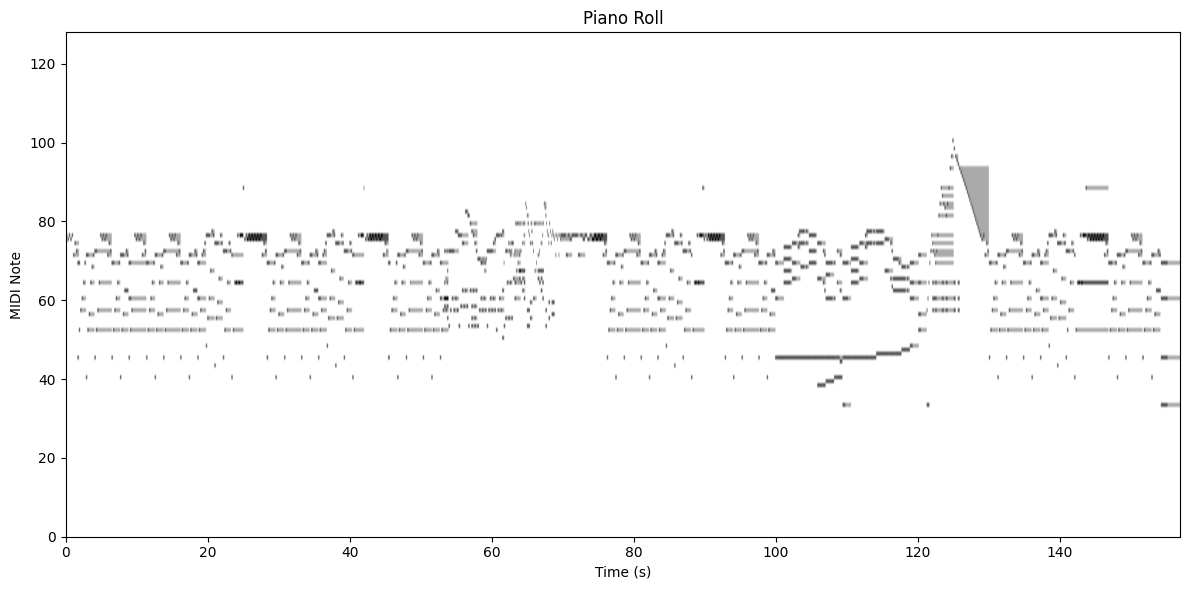

In [15]:
# Plot example midi
plot_piano_roll(example_midi_path)

In [29]:
# Set sample filename and path
sample_file_name = os.path.basename(sample_path)

audio_path = f'{chunks_directory}/{Path(sample_file_name.replace('.mid','.wav'))}'

print(f'Sample_file_name: {sample_file_name}')
print(f'Audio Path: {audio_path}')

Sample_file_name: elise.mid
Audio Path: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise.wav


## 2.3 - Creating audio chunks from MIDI files

In [1]:
# Ensure the base chunks directory exists
Path(chunks_directory).mkdir(parents=True, exist_ok=True)

print(f"Processing MIDI files from: {midi_directory}")
print(f"Saving audio chunks to: {chunks_directory}\n")

processed_midi_count = 0

for root, _, files in os.walk(midi_directory):
    for file in files:
        if file.endswith(('.mid', '.midi')):
            midi_file_path = os.path.join(root, file)

            # Construct the relative path from midi_directory
            relative_path = os.path.relpath(midi_file_path, midi_directory)

            # Create the corresponding output subdirectory within chunks_directory
            # The parent directory of the .wav file will be the new subfolder for the melody
            output_base_dir = os.path.join(chunks_directory, Path(relative_path).parent)
            Path(output_base_dir).mkdir(parents=True, exist_ok=True)

            # Construct the audio_path for the current MIDI file
            # This will be the base name for the WAV files 
            audio_path = os.path.join(output_base_dir, Path(file).stem)
            # The create_chunks_from_midi function will append _chunk_X.wav
            Path(audio_path).mkdir(parents=True, exist_ok=True)
            audio_file_name_base = Path(file).stem + '.wav'
            audio_path = os.path.join(audio_path, audio_file_name_base)

            try:
                create_chunks_from_midi(midi_file_path, sr=24000, chunk_size=32, audio_path=audio_path)
                processed_midi_count += 1
            except Exception as e:
                print(f"Error processing {midi_file_path}: {e}")

print(f"\nFinished processing {processed_midi_count} MIDI files.")

Streaming output truncated to the last 5000 lines.

Finished processing 292 MIDI files.


In [ ]:
# Load MERT model
model_name = "m-a-p/MERT-v1-95M"

processor = AutoProcessor.from_pretrained(
    model_name,
    trust_remote_code=True
)

model = AutoModel.from_pretrained(
    model_name,
    trust_remote_code=True
)

model.eval()

print("MERT model loaded successfully")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

MERT model loaded successfully


In [ ]:
# Get a list of all .wav files in the chunks_directory
chunk_wav_files = [
    os.path.join(chunks_directory, f)
    for f in os.listdir(chunks_directory)
    if f.endswith(".wav")
]

# Sort the files for consistent processing order
chunk_wav_files.sort()

print(f"Found {len(chunk_wav_files)} WAV chunk files in {chunks_directory}")

all_chunk_embeddings = []

for i, wav_file in enumerate(chunk_wav_files):
    print(f"Processing chunk {i+1}/{len(chunk_wav_files)}: {wav_file}")
    try:
        # Load the audio file
        audio_input, sampling_rate = sf.read(wav_file)

        # Process the audio to get features MERT expects
        inputs = processor(raw_speech=audio_input, sampling_rate=sampling_rate, return_tensors="pt")

        # Generate embeddings
        with torch.no_grad():
            outputs = model(**inputs)

        # The MERT model outputs a 'last_hidden_state' which are the embeddings
        # We can take the mean across the time dimension to get a single embedding per chunk
        chunk_embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
        all_chunk_embeddings.append(chunk_embedding)
        print(f"  Generated embedding of shape: {chunk_embedding.shape}")

    except Exception as e:
        print(f"Error processing {wav_file}: {e}")

print("\nFinished generating embeddings for all chunks.")

# Convert list of embeddings to a numpy array for easier handling
if all_chunk_embeddings:
    all_chunk_embeddings_array = np.array(all_chunk_embeddings)
    print(f"Total embeddings array shape: {all_chunk_embeddings_array.shape}")
else:
    print("No embeddings were generated.")

Found 33 WAV chunk files in /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples
Processing chunk 1/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise.wav
  Generated embedding of shape: (768,)
Processing chunk 2/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_1.wav
  Generated embedding of shape: (768,)
Processing chunk 3/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_10.wav
  Generated embedding of shape: (768,)
Processing chunk 4/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_11.wav
  Generated embedding of shape: (768,)
Processing chunk 5/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_12.wav
  Generated embedding of shape: (768,)
Processing chunk 6/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_13.wav
  Generated embedding of shape: (768,)
Processing chunk 7/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_14.wav
  Gene

In [ ]:
# Display values of chunk embedding array
all_chunk_embeddings_array

array([[-0.06526169, -0.08986434,  0.01106025, ..., -0.12569161,
         0.01292511,  0.15875973],
       [-0.05605015,  0.02903162,  0.1476077 , ...,  0.06878751,
        -0.12339675, -0.01053775],
       [-0.00215679,  0.06864046,  0.10211527, ...,  0.07713242,
        -0.158657  ,  0.07421888],
       ...,
       [-0.04903139,  0.0355635 ,  0.10422671, ...,  0.08874337,
        -0.03504748, -0.09810561],
       [-0.02771215, -0.02110263,  0.1903375 , ..., -0.0028037 ,
        -0.1456412 , -0.02211083],
       [-0.06512479,  0.02299381,  0.1268365 , ...,  0.04886309,
        -0.07233655, -0.11230969]], dtype=float32)

In [ ]:
# Calculate the cosine similarity matrix
cosine_sim_matrix = cosine_similarity(all_chunk_embeddings_array)

print("Cosine Similarity Matrix shape:", cosine_sim_matrix.shape)
print("\nFirst 5x5 block of the Cosine Similarity Matrix:")
display(cosine_sim_matrix[:5, :5])

Cosine Similarity Matrix shape: (33, 33)

First 5x5 block of the Cosine Similarity Matrix:


array([[0.9999999 , 0.3274981 , 0.33961865, 0.33189514, 0.31973848],
       [0.3274981 , 1.0000002 , 0.9625899 , 0.92657423, 0.9624461 ],
       [0.33961865, 0.9625899 , 0.99999994, 0.96453846, 0.98271596],
       [0.33189514, 0.92657423, 0.96453846, 1.        , 0.96836454],
       [0.31973848, 0.9624461 , 0.98271596, 0.96836454, 0.9999998 ]],
      dtype=float32)

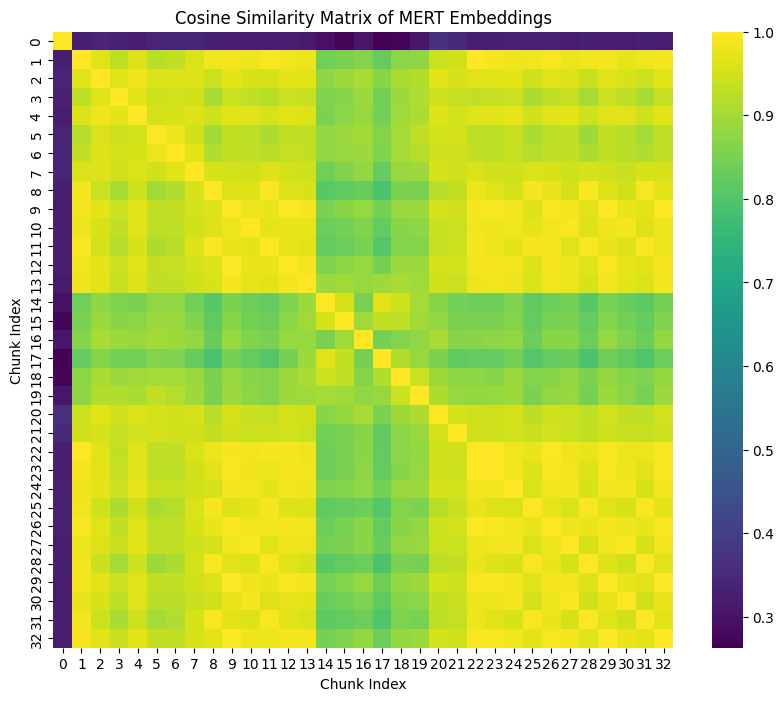

In [ ]:
# Plot Similarity Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim_matrix, annot=False, cmap='viridis', fmt=".2f", cbar=True)
plt.title('Cosine Similarity Matrix of MERT Embeddings')
plt.xlabel('Chunk Index')
plt.ylabel('Chunk Index')
plt.show()

The output `cosine_sim_matrix` is a square matrix where `cosine_sim_matrix[i, j]` represents the cosine similarity between the embedding

of chunk `i` and chunk `j`. Values close to 1 indicate high similarity, while values close to -1 indicate high dissimilarity.

The diagonal elements will always be 1, as an embedding is perfectly similar to itself.

# 2.4 Note Pitch EDA
### DataExploration.ipynb

### Load MidiDatasets

In [25]:
# midi_directory and excluded_directory are assumed to be Path objects or strings
midi_directory = Path(
    "/content/drive/MyDrive/capstone_team_3/MidiDatasets/590-Classical-music-midi"
)

#  List of directories 
print("List of directories in midi_directory:")
for item in midi_directory.iterdir():
    if item.is_dir():
        print(item.name)

List of directories in midi_directory:
muss
borodin
beeth
mozart
debussy
bach
haydn
granados
schumann
albeniz
grieg
mendelssohn
burgm
chopin
liszt
balakir
tschai
schubert
brahms


In [26]:
# Load the MIDI files and extract features using pretty_midi
midi_files = []
for root, dirs, files in os.walk(midi_directory):
    for file in files:
        if file.endswith('.mid') or file.endswith('.midi'):
            midi_files.append(os.path.join(root, file))
print(f"Total MIDI files found: {len(midi_files)}")
# Example of loading a MIDI file and extracting features
if midi_files:
    midi_path = midi_files[0]  # Load the first MIDI file as an example
    midi_data = pretty_midi.PrettyMIDI(midi_path)
    print(f"Loaded MIDI file: {midi_path}")
    print(f"Number of instruments: {len(midi_data.instruments)}")
    print(f"Total duration: {midi_data.get_end_time()} seconds")

Total MIDI files found: 292
Loaded MIDI file: /content/drive/MyDrive/capstone_team_3/MidiDatasets/590-Classical-music-midi/muss/muss_6.mid
Number of instruments: 2
Total duration: 126.4340885 seconds


In [ ]:
# Create a dataset of MIDI features for training the model
def extract_features(midi_data):
    features = []
    for instrument in midi_data.instruments:
        for note in instrument.notes:
            #  duration, pitch, velocity, pitch_diff    
            features.append([note.start, note.end, note.pitch, note.velocity])
    return np.array(features)   

midi_features = []
for midi_path in midi_files:
    midi_data = pretty_midi.PrettyMIDI(midi_path)
    features = extract_features(midi_data)
    midi_features.append(features)
print(f"Extracted features from {len(midi_features)} MIDI files.")

Extracted features from 292 MIDI files.


In [24]:
# Convert the list of features into a format suitable for training (e.g., numpy array)
midi_features_array = np.array(midi_features, dtype=object)  # Using dtype=object to handle variable-length feature arrays
print(f"Shape of MIDI features array: {midi_features_array.shape}")
#Store the extracted features for later use as CSV or binary file
import pandas as pd
# Convert the list of features into a DataFrame for easier storage and manipulation
features_df = pd.DataFrame(midi_features_array, columns=['features'])
# Save the DataFrame to a CSV file
features_df.to_csv('/content/drive/MyDrive/capstone_team_3/midi_features.csv', index=False)
print("MIDI features saved to CSV file.")   

Shape of MIDI features array: (292,)
MIDI features saved to CSV file.


### Visualizaton of Midi

Text(0, 0.5, 'Frequency')

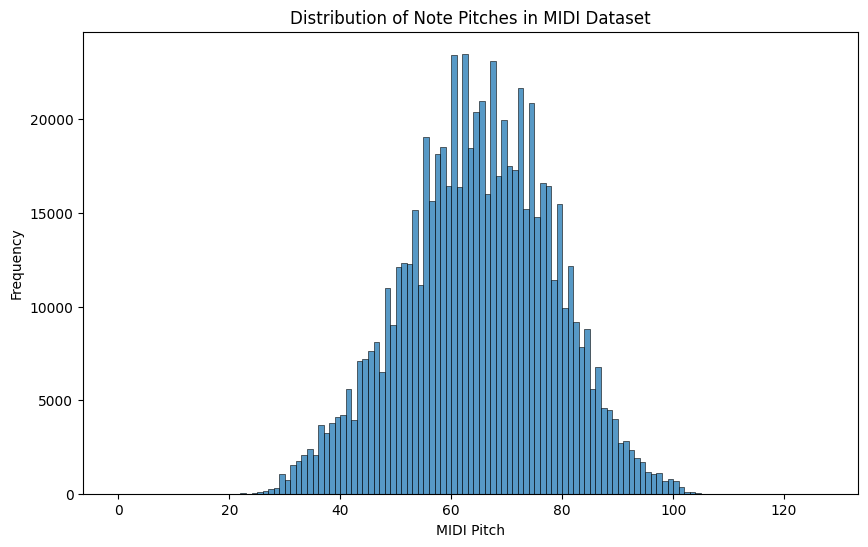

In [27]:
# Visualize the distribution of note pitches across all MIDI files
all_pitches = []
for features in midi_features:
    if features.size > 0:  # Check if there are features to avoid errors
        all_pitches.extend(features[:, 2])  # Extract the pitch column (index 2)
# Plot the distribution of note pitches using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(all_pitches, bins=range(0, 128), kde=False)
plt.title('Distribution of Note Pitches in MIDI Dataset')
plt.xlabel('MIDI Pitch')
plt.ylabel('Frequency')     

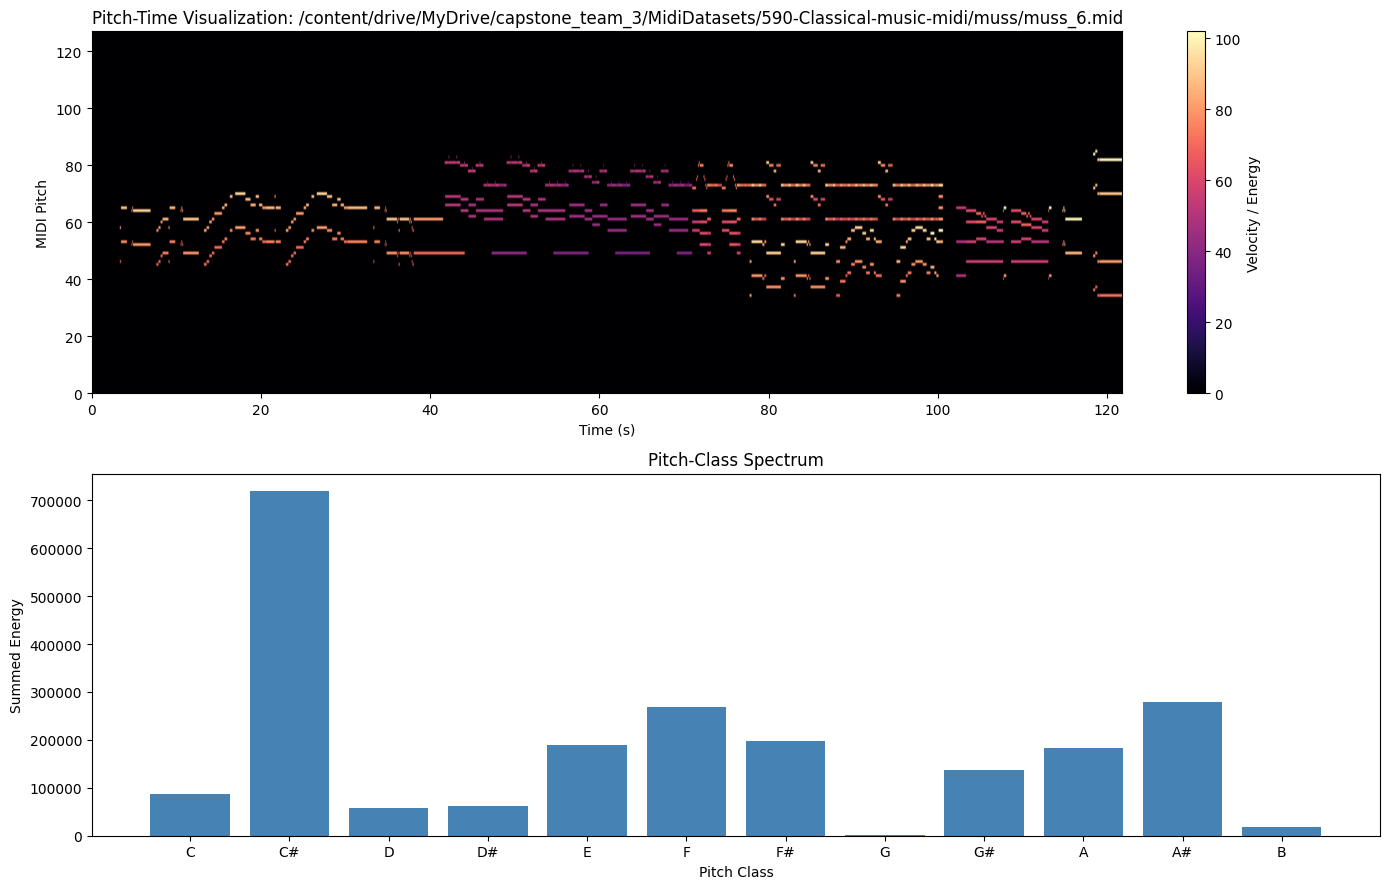

In [28]:
# Visualize one MIDI file by pitch over time and pitch-class spectrum
if not midi_files:
    print("No MIDI files available to visualize.")
else:
    # Pick a MIDI file (you can change index to inspect others)
    midi_idx = 0
    midi_path = midi_files[midi_idx]
    midi_data = pretty_midi.PrettyMIDI(midi_path)

    # Piano roll: rows=pitches (0-127), cols=time frames
    fs = 100  # frames per second
    piano_roll = midi_data.get_piano_roll(fs=fs)

    # Build a simple pitch-class spectrum (C..B) from total note energy
    chroma = np.zeros(12)
    if piano_roll.size > 0:
        for pitch in range(128):
            chroma[pitch % 12] += piano_roll[pitch].sum()

    # Time axis for piano roll
    time_axis = np.arange(piano_roll.shape[1]) / fs if piano_roll.size > 0 else np.array([0])

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    # Plot 1: Pitch-time heatmap
    if piano_roll.size > 0:
        im = axes[0].imshow(
            piano_roll,
            origin='lower',
            aspect='auto',
            cmap='magma',
            extent=[time_axis.min(), time_axis.max(), 0, 127]
        )
        fig.colorbar(im, ax=axes[0], label='Velocity / Energy')
    axes[0].set_title(f'Pitch-Time Visualization: {midi_path}')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('MIDI Pitch')

    # Plot 2: Pitch-class spectrum
    note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    axes[1].bar(note_names, chroma, color='steelblue')
    axes[1].set_title('Pitch-Class Spectrum')
    axes[1].set_xlabel('Pitch Class')
    axes[1].set_ylabel('Summed Energy')

    plt.tight_layout()
    plt.show()

# 2.5 Similarity Score EDA
### Similarity_Score_EDA.ipynb

- **Features:** pitch, duration, tempo, scale (1=major, 0=minor)  
- **Chunking:** time-based or fixed note count  
- **Per-feature similarity:**  
  similarity = 1 - |a - b| / max(|a|, |b|)  
- **Per-chunk:** mean of feature similarities  
- **Final:** mean of all chunks  

**Output:** single score (0–1) measuring match to reference MIDI

In [26]:
##########################
# 2.5.1 - Loading MIDI for comparison
##########################

# Reference MIDI (true Fur Elise)
ref_midi_path = "MidiDatasets/590-Classical-music-midi/beeth/elise.mid"

# Input MIDIs to compare
input_midi_paths = [
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_2ndVerse_K-Amin_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_2ndVerse_K-Bmin_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_2ndVerse_K-Gmin_T-75_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_4thVerse_K-Amin_T-79_bothhands.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_4thVerse_K-Gmin_T-63_bothhands.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro-2ndVers_K-Amin_T-70_bothhands.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro_K-Amaj_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro_K-Amin_T-138_righthand_swing.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro_K-Amin_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro_K-Cmaj_T-70_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro_K-Cmin_T-60_righthand.mid",
]

# Encode scale: major=1, minor=0
def scale_to_num(scale_str):
    return 1 if "maj" in scale_str.lower() else 0

def extract_note_features(midi_path, scale_num=0):
    midi = pretty_midi.PrettyMIDI(midi_path)
    tempo = midi.estimate_tempo()
    notes = []
    for inst in midi.instruments:
        for n in inst.notes:
            duration = n.end - n.start
            feature = [n.pitch, duration, tempo, scale_num]
            notes.append((n.start, feature))
    notes.sort(key=lambda x: x[0])
    return [f[1] for f in notes]


##########################
# 2.5.2 - Chunking and similarity calculations
##########################

def chunk_by_note_count(features, chunk_size=5):
    chunks = []
    for i in range(0, len(features), chunk_size):
        chunk = features[i:i+chunk_size]
        if len(chunk) == chunk_size:
            chunks.append(np.array(chunk))
    return chunks

def chunk_by_time(features, window=2.0):
    chunks = []
    current = []
    start_time = 0
    for i, feat in enumerate(features):
        note_start = i  # approximate sequential index for simplicity
        if note_start - start_time <= window:
            current.append(feat)
        else:
            chunks.append(np.array(current))
            current = [feat]
            start_time = note_start
    if current:
        chunks.append(np.array(current))
    return chunks

# Cosine similarity per feature
def compute_feature_similarity(ref_chunks, input_chunks):
    pitch_sims, duration_sims, tempo_sims, scale_sims = [], [], [], []
    min_len = min(len(ref_chunks), len(input_chunks))
    
    for i in range(min_len):
        ref = ref_chunks[i]
        inp = input_chunks[i]
        
        # Using normalized absolute difference instead of cosine similarity
        # 1.0 = identical, 0.0 = completely different
        def calc_score(a, b):
            min_len = min(len(a), len(b))
            a, b = a[:min_len], b[:min_len]
            diff = np.abs(a - b)
            denom = np.maximum(np.abs(a), np.abs(b))
            denom[denom == 0] = 1  # avoid div by zero
            return np.mean(1 - (diff / denom))

        pitch_sims.append(calc_score(ref[:, 0], inp[:, 0]))
        duration_sims.append(calc_score(ref[:, 1], inp[:, 1]))
        tempo_sims.append(calc_score(ref[:, 2], inp[:, 2]))
        scale_sims.append(calc_score(ref[:, 3], inp[:, 3]))
        
    overall_sims = np.mean([pitch_sims, duration_sims, tempo_sims, scale_sims], axis=0)
    return pitch_sims, duration_sims, tempo_sims, scale_sims, overall_sims


##########################
# 2.5.3 - Compute similarities and prepare for plotting
##########################

results = []

for path in input_midi_paths:
    scale_num = 1 if "_maj_" in path.lower() else 0
    ref_features = extract_note_features(ref_midi_path, scale_num)
    input_features = extract_note_features(path, scale_num)
    
    # Chunk by time
    ref_time_chunks = chunk_by_time(ref_features, 2.0)
    input_time_chunks = chunk_by_time(input_features, 2.0)
    pitch_t, dur_t, tempo_t, scale_t, overall_t = compute_feature_similarity(ref_time_chunks, input_time_chunks)
    
    # Chunk by note count
    ref_note_chunks = chunk_by_note_count(ref_features, 5)
    input_note_chunks = chunk_by_note_count(input_features, 5)
    pitch_n, dur_n, tempo_n, scale_n, overall_n = compute_feature_similarity(ref_note_chunks, input_note_chunks)
    
    results.append({
        "file": path.split("/")[-1],
        "time_pitch": np.mean(pitch_t),
        "time_duration": np.mean(dur_t),
        "time_tempo": np.mean(tempo_t),
        "time_scale": np.mean(scale_t),
        "time_overall": np.mean(overall_t),
        "note_pitch": np.mean(pitch_n),
        "note_duration": np.mean(dur_n),
        "note_tempo": np.mean(tempo_n),
        "note_scale": np.mean(scale_n),
        "note_overall": np.mean(overall_n)
    })

df = pd.DataFrame(results)

# 2.5.4 Plot Grouped Similarity Scores
- comparing chunks grouped by similarity scores:
      <BR>low (lowest 33% of all scores) medium (middle 33% of all scores) and high (highest 33% of all scores) 
- comparing best and worst similarity score chunks

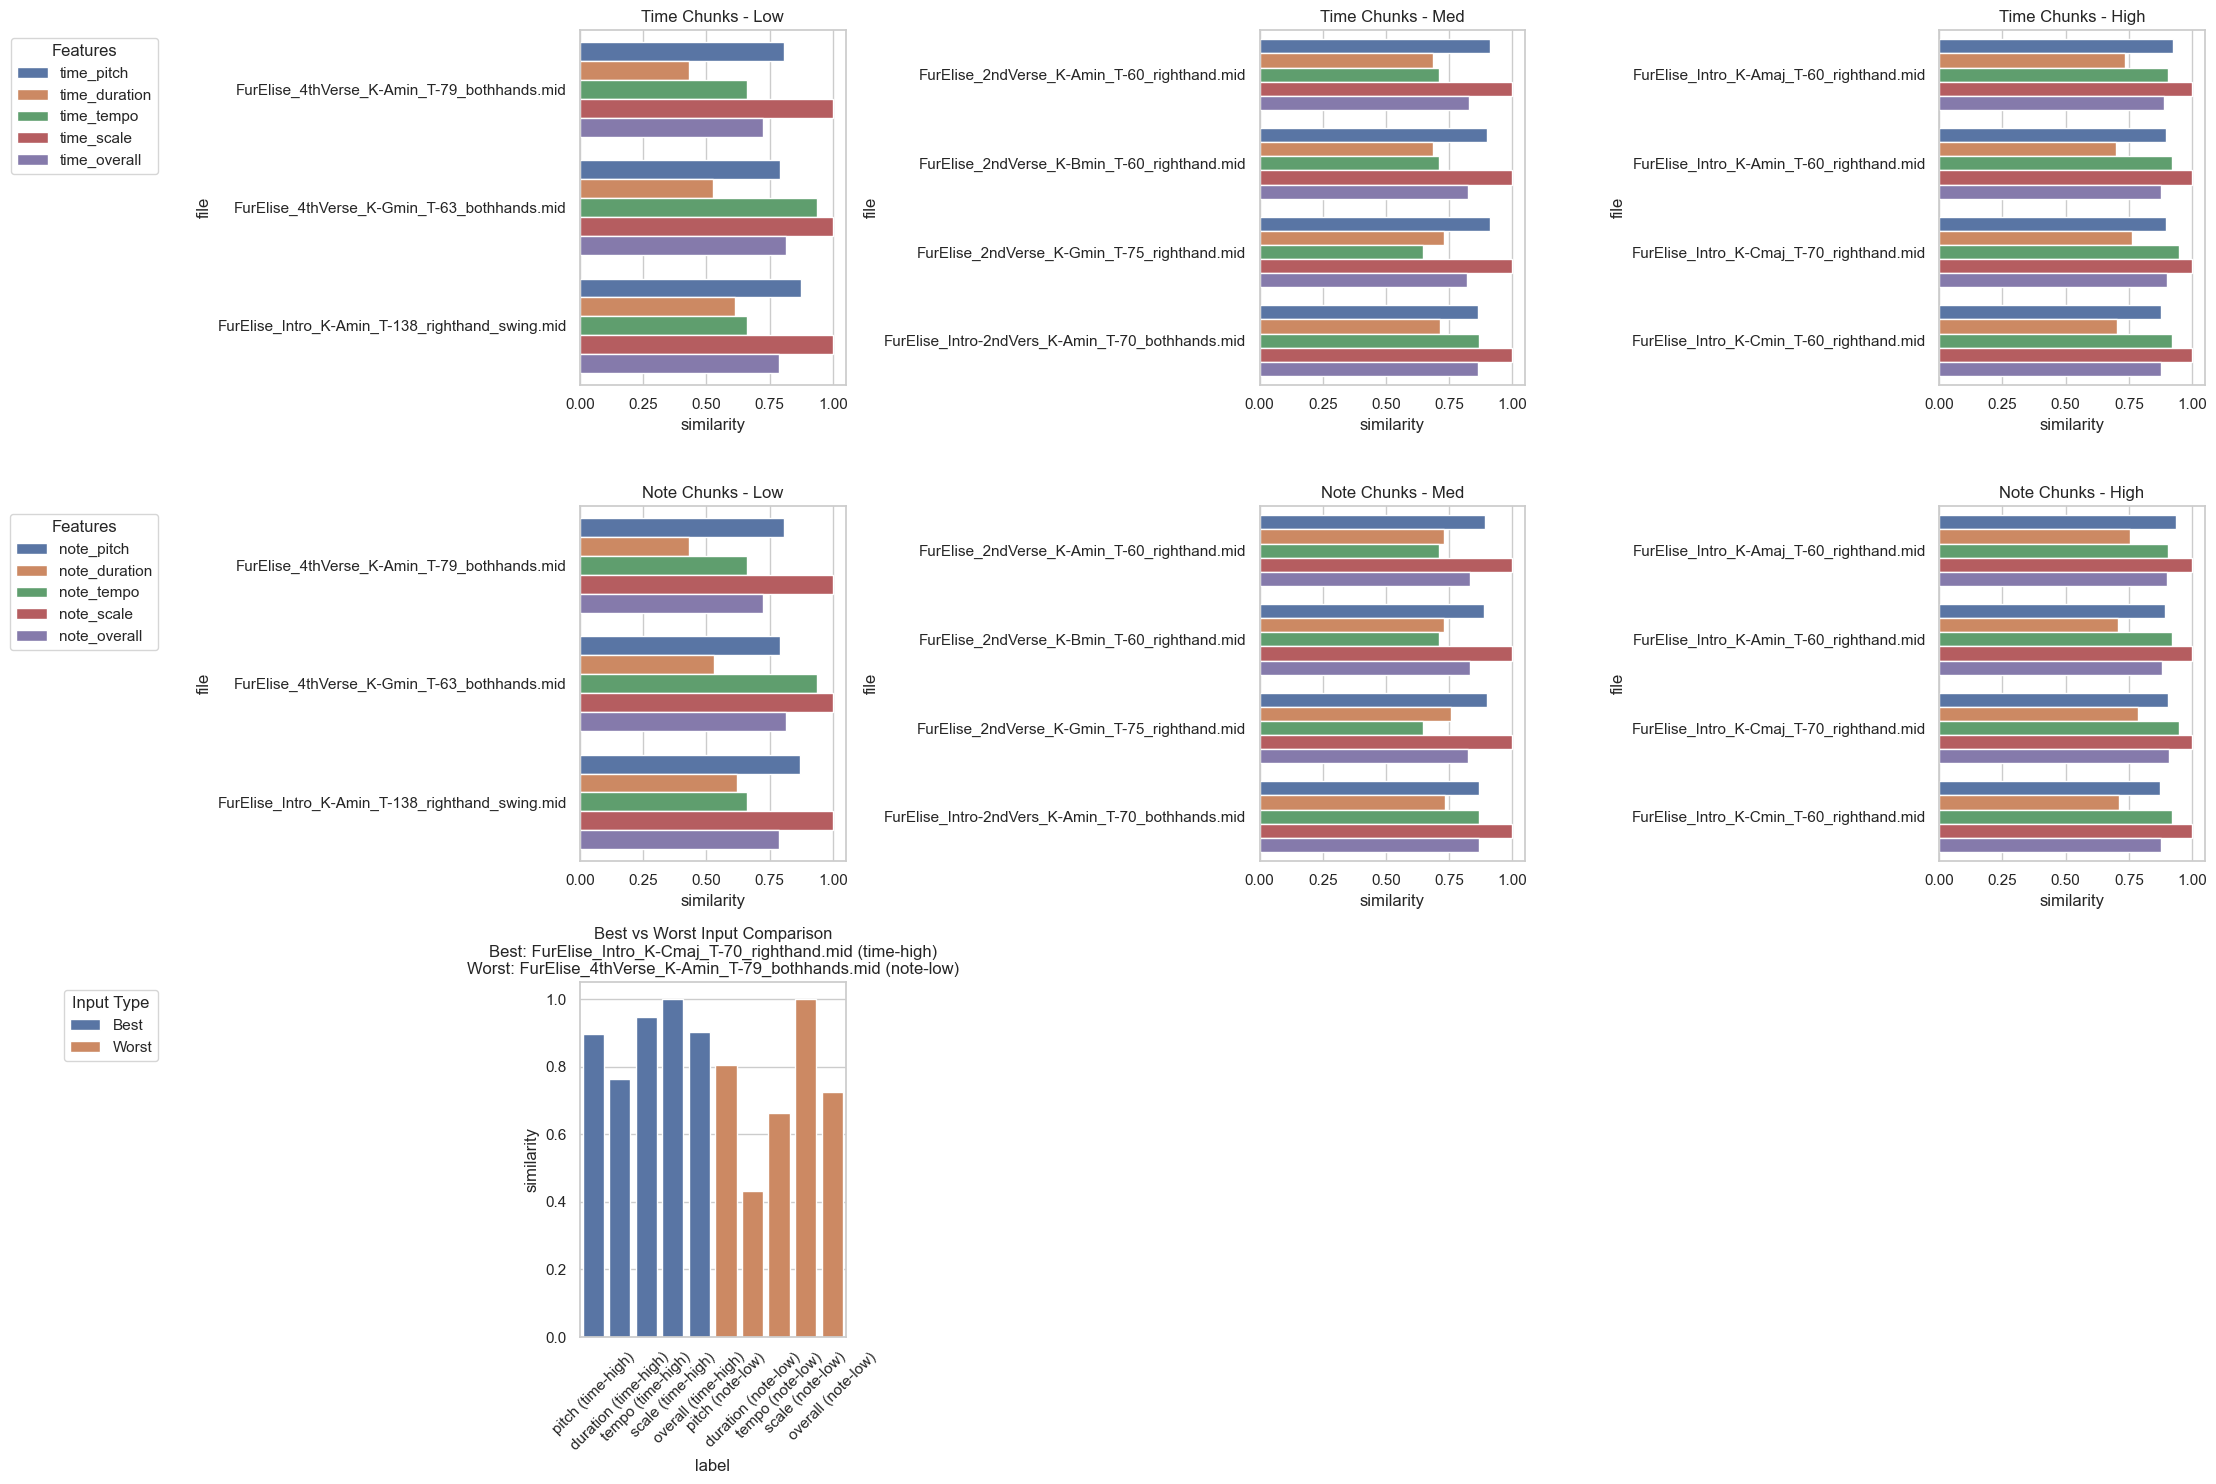

In [27]:
##########################
# 2.5.4 - Combined plotting with legends only in first column
##########################

sns.set(style="whitegrid")

# Melt for Seaborn
df_time = df.melt(
    id_vars="file",
    value_vars=["time_pitch","time_duration","time_tempo","time_scale","time_overall"],
    var_name="feature",
    value_name="similarity"
)
df_note = df.melt(
    id_vars="file",
    value_vars=["note_pitch","note_duration","note_tempo","note_scale","note_overall"],
    var_name="feature",
    value_name="similarity"
)

fig, axes = plt.subplots(3, 4, figsize=(22, 15), gridspec_kw={'width_ratios':[0.15,1,1,1]})

# Hide first column axes for legend placeholders
for row in range(3):
    axes[row,0].axis('off')

# Helper: split files by low/med/high based on overall
def get_split_files(df, col, split):
    sorted_files = df.sort_values(col)["file"].values
    n = len(sorted_files)
    if split == "low":
        return sorted_files[:n//3]
    elif split == "med":
        return sorted_files[n//3:2*n//3]
    elif split == "high":
        return sorted_files[2*n//3:]
    else:
        return sorted_files

# --- Row 1: Time chunks ---
for i, split in enumerate(["low", "med", "high"]):
    sns.barplot(
        x="similarity", y="file", hue="feature",
        data=df_time[df_time["file"].isin(get_split_files(df, "time_overall", split))],
        ax=axes[0,i+1]
    )
    axes[0,i+1].set_title(f"Time Chunks - {split.capitalize()}")
    axes[0,i+1].legend_.remove()  # remove individual legend

# Assign legend to first column
handles, labels = axes[0,1].get_legend_handles_labels()
axes[0,0].legend(handles, labels, title="Features")
axes[0,0].axis('off')

# --- Row 2: Note chunks ---
for i, split in enumerate(["low", "med", "high"]):
    sns.barplot(
        x="similarity", y="file", hue="feature",
        data=df_note[df_note["file"].isin(get_split_files(df, "note_overall", split))],
        ax=axes[1,i+1]
    )
    axes[1,i+1].set_title(f"Note Chunks - {split.capitalize()}")
    axes[1,i+1].legend_.remove()  # remove individual legend

# Assign legend to first column
handles, labels = axes[1,1].get_legend_handles_labels()
axes[1,0].legend(handles, labels, title="Features")
axes[1,0].axis('off')

# --- Row 3: Best vs Worst Input Comparison ---
axes[2,2].axis('off')
axes[2,3].axis('off')

if not df.empty:
    df["overall_avg"] = df[["time_overall","note_overall"]].mean(axis=1)
    best_row = df.loc[df["overall_avg"].idxmax()]
    worst_row = df.loc[df["overall_avg"].idxmin()]

    def get_split_label(row, chunk_type):
        if chunk_type == "time":
            if row["file"] in get_split_files(df, "time_overall", "low"): return "low"
            elif row["file"] in get_split_files(df, "time_overall", "med"): return "med"
            else: return "high"
        else:
            if row["file"] in get_split_files(df, "note_overall", "low"): return "low"
            elif row["file"] in get_split_files(df, "note_overall", "med"): return "med"
            else: return "high"

    best_worst_df = pd.DataFrame([
        {"feature":"pitch", "similarity":best_row["time_pitch"], "input_type":"Best", "chunk":"time", "split":get_split_label(best_row,"time")},
        {"feature":"duration", "similarity":best_row["time_duration"], "input_type":"Best", "chunk":"time", "split":get_split_label(best_row,"time")},
        {"feature":"tempo", "similarity":best_row["time_tempo"], "input_type":"Best", "chunk":"time", "split":get_split_label(best_row,"time")},
        {"feature":"scale", "similarity":best_row["time_scale"], "input_type":"Best", "chunk":"time", "split":get_split_label(best_row,"time")},
        {"feature":"overall", "similarity":best_row["time_overall"], "input_type":"Best", "chunk":"time", "split":get_split_label(best_row,"time")},
        {"feature":"pitch", "similarity":worst_row["note_pitch"], "input_type":"Worst", "chunk":"note", "split":get_split_label(worst_row,"note")},
        {"feature":"duration", "similarity":worst_row["note_duration"], "input_type":"Worst", "chunk":"note", "split":get_split_label(worst_row,"note")},
        {"feature":"tempo", "similarity":worst_row["note_tempo"], "input_type":"Worst", "chunk":"note", "split":get_split_label(worst_row,"note")},
        {"feature":"scale", "similarity":worst_row["note_scale"], "input_type":"Worst", "chunk":"note", "split":get_split_label(worst_row,"note")},
        {"feature":"overall", "similarity":worst_row["note_overall"], "input_type":"Worst", "chunk":"note", "split":get_split_label(worst_row,"note")},
    ])

    best_worst_df["label"] = best_worst_df["feature"] + " (" + best_worst_df["chunk"] + "-" + best_worst_df["split"] + ")"

    sns.barplot(
        x="label", y="similarity",
        hue="input_type", data=best_worst_df, ax=axes[2,1]
    )
    axes[2, 1].set_title(
        (
            "Best vs Worst Input Comparison\n"
            f"Best: {best_row['file']} "
            f"({best_worst_df[best_worst_df['input_type'] == 'Best']['chunk'].iloc[0]}-"
            f"{best_worst_df[best_worst_df['input_type'] == 'Best']['split'].iloc[0]})\n"
            f"Worst: {worst_row['file']} "
            f"({best_worst_df[best_worst_df['input_type'] == 'Worst']['chunk'].iloc[0]}-"
            f"{best_worst_df[best_worst_df['input_type'] == 'Worst']['split'].iloc[0]})"
        )
    )
    axes[2,1].tick_params(axis='x', rotation=45)

    # Assign legend only in first column
    handles, labels = axes[2,1].get_legend_handles_labels()
    axes[2,0].legend(handles, labels, title="Input Type")
    axes[2,0].axis('off')

    # Remove duplicate legend in plot
    axes[2,1].legend_.remove()
else:
    axes[2,1].text(0.5, 0.5, "No valid MIDI comparisons", ha='center', va='center')
    axes[2,1].axis('off')
    axes[2,0].axis('off')

plt.tight_layout()
plt.show()

# 3. Feature Engineering
### FeatureEngineering.ipynb
-  Data Loading: It scans a directory for MIDI files from Google Drive.

-  Feature Extraction: For each MIDI file, it uses the pretty_midi library to extract three specific numerical features per note:

   duration, pitch difference (relative to the previous note), and velocity.

-  Sequence Generation: It transforms the raw note features into windowed sequences of a fixed length (256 notes).

   Each sequence is labeled with its corresponding MIDI filename for supervised learning tasks.

-  Data Storage and Splitting: The final processed data is saved into pickle files for efficient retrieval and is split into a training set (80%) and a testing set (20%).

-  External Evaluation Prep: It includes a separate pipeline to process 50 additional "external" MIDI samples to create a standalone evaluation dataset.

### Load MidiDatasets

In [3]:
# Midi_directory and excluded_directory are assumed to be Path objects or strings
midi_directory = Path("/content/drive/MyDrive/capstone_team_3/MidiDatasets/590-Classical-music-midi")

In [4]:
# Load the MIDI files and extract features using pretty_midi
midi_files = []
for root, dirs, files in os.walk(midi_directory):
    for file in files:
        if file.endswith('.mid') or file.endswith('.midi'):
            midi_files.append(os.path.join(root, file))
print(f"Total MIDI files found: {len(midi_files)}")

Total MIDI files found: 292


In [5]:
# Extract features from MIDI data with duration, pitch_diff, velocity
def extract_features(midi_data):
        features = []
        previous_pitch = None
        for instrument in midi_data.instruments:
            for note in instrument.notes:
                #  duration, pitch, velocity, pitch_diff    
                pitch_diff = note.pitch - previous_pitch if previous_pitch is not None else 0
                features.append([note.end - note.start, pitch_diff, note.velocity])
                previous_pitch = note.pitch
        return np.array(features)   

In [6]:
midi_features = []
for midi_path in midi_files:
    midi_data = pretty_midi.PrettyMIDI(midi_path)
    features = extract_features(midi_data)
    midi_features.append(features)
print(f"Extracted features from {len(midi_features)} MIDI files.")

Extracted features from 292 MIDI files.


In [11]:
# Convert the list of features into a format suitable for training (e.g., numpy array)
midi_features_array = np.array(midi_features, dtype=object)  # Using dtype=object to handle variable-length feature arrays
print(f"Shape of MIDI features array: {midi_features_array.shape}")
#Store the extracted features for later use as CSV or binary file
import pandas as pd
# Convert the list of features into a DataFrame for easier storage and manipulation
features_df = pd.DataFrame(midi_features_array, columns=['features'])
# Add file names or identifiers if needed (optional)
features_df['file_name'] = [os.path.basename(path) for path in midi_files]  
# Save the DataFrame to picklet format for efficient storage
features_df.to_pickle('/content/drive/MyDrive/capstone_team_3/midi_features.pkl')
print("MIDI features saved to pickle file.") 

Shape of MIDI features array: (292,)
MIDI features saved to pickle file.


In [12]:
# load the features from the pickle file
loaded_features_df = pd.read_pickle('/content/drive/MyDrive/capstone_team_3/midi_features.pkl')
print("MIDI features loaded from pickle file.")
print(f"Shape of loaded MIDI features DataFrame: {loaded_features_df.shape}")

MIDI features loaded from pickle file.
Shape of loaded MIDI features DataFrame: (292, 2)


In [13]:
# Convert the pitch into  windowed sequences for training a sequence model
def create_sequences(features, sequence_length=256):
    sequences = []
    for i in range(len(features) - sequence_length):
        seq = features[i:i + sequence_length]
        sequences.append(seq)
    return np.array(sequences)
# use loaded_features_df to create sequences for training
# Covvert the all the midi features into sequences for training,  Each sequence will be a window of 50 notes (or other features) for training a model like an LSTM or Transformer. Label the sequences appropriately for supervised learning, give the name of the midi file as the label for each sequence.
all_sequences = []
for midi_path, features in zip(loaded_features_df['file_name'], loaded_features_df['features']):
    if features.size > 0:  # Check if there are features to avoid errors
        sequences = create_sequences(features)
        file_name = os.path.basename(midi_path)  # Get the file name from the path
        labels = [file_name] * len(sequences)  # Label each sequence with the MIDI file name
        all_sequences.extend(zip(sequences, labels))
print(f"Total sequences created: {len(all_sequences)}")

# Create a DF for the sequences and labels
sequences_df = pd.DataFrame(all_sequences, columns=['sequence', 'label'])
print(f"Shape of sequences DataFrame: {sequences_df.shape}")

Total sequences created: 630987
Shape of sequences DataFrame: (630987, 2)


In [14]:
# Show sequences dataframe
sequences_df.head()

,sequence,label
0,"[[0.12396699999999994, 0.0, 80.0], [0.71005899...",muss_6.mid
1,"[[0.7100589999999998, 7.0, 88.0], [0.088757375...",muss_6.mid
2,"[[0.08875737500000014, -1.0, 80.0], [0.0887573...",muss_6.mid
3,"[[0.08875737500000014, 1.0, 80.0], [2.080926, ...",muss_6.mid
4,"[[2.080926, -1.0, 92.0], [0.24242433333333313,...",muss_6.mid


In [20]:
# Store the sequences and labels for training
sequences_df.to_pickle('/content/drive/MyDrive/capstone_team_3/data_set/classic_midi_sequences_256.pkl')
print("MIDI sequences saved to pickle file.")   

MIDI sequences saved to pickle file.


In [21]:
# Load the sequences and labels for training
loaded_sequences_df = pd.read_pickle('/content/drive/MyDrive/capstone_team_3/data_set/classic_midi_sequences_256.pkl')
print("MIDI sequences loaded from pickle file.")
print(f"Shape of loaded sequences DataFrame: {loaded_sequences_df.shape}")  

MIDI sequences loaded from pickle file.
Shape of loaded sequences DataFrame: (630987, 2)


In [23]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(loaded_sequences_df, test_size=0.2, random_state=42)
print(f"Training set size: {len(train_df)}")
print(f"Testing set size: {len(test_df)}")  

Training set size: 504789
Testing set size: 126198


In [24]:
# Create list of test sequences from test midi path
test_sequences = []
test_midi_directory = Path("/content/drive/MyDrive/capstone_team_3/MidiDatasets/TestingSamples/MidiOutputs")
test_files=[]
for root, dirs, files in os.walk(test_midi_directory):
    for file in files:
        if file.endswith('.mid') or file.endswith('.midi'):
            midi_path = os.path.join(root, file)
            midi_data = pretty_midi.PrettyMIDI(midi_path)
            features = extract_features(midi_data)
            file_name = os.path.basename(midi_path)  # Get the file name from the path
            test_sequences.append((features, file))  # Store features and filename as label
print(f"Total test MIDI sequences created: {len(test_sequences)}")

/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Total test MIDI sequences created: 50


In [25]:
# Merge the test sequences ,filename and features into a single list for evaluation
merged_test_sequences = []
# Store each sequence with the MIDI file name as label
for features, filename in test_sequences:
    if features.size > 0:
        sequences = create_sequences(features)
        for seq in sequences:
            merged_test_sequences.append((seq, filename))  # Store each sequence with the MIDI file name as label

In [27]:
# Create a DATAFRAME for the merged test sequences
external_test_df = pd.DataFrame(merged_test_sequences, columns=['sequence', 'label'])
print(f"Shape of merged test sequences DataFrame: {external_test_df.shape}")
print("Sample merged test sequences:")
external_test_df.head()

Shape of merged test sequences DataFrame: (203723, 2)
Sample merged test sequences:


,sequence,label
0,"[[0.7999999999999998, 0.0, 44.0], [0.300000000...",Piano Sonata n12 K332.mid
1,"[[0.30000000000000027, 4.0, 47.0], [0.79999999...",Piano Sonata n12 K332.mid
2,"[[0.7999999999999998, 3.0, 49.0], [0.304166666...",Piano Sonata n12 K332.mid
3,"[[0.3041666666666667, -3.0, 52.0], [0.79999999...",Piano Sonata n12 K332.mid
4,"[[0.7999999999999998, 1.0, 54.0], [0.299999999...",Piano Sonata n12 K332.mid


In [29]:
# Save the sequences DataFrame to a pickle file for later use
external_test_df.to_pickle('/content/drive/MyDrive/capstone_team_3/data_set/external_test_sequences.pkl')
print("External test sequences saved to pickle file.")  

External test sequences saved to pickle file.


# 4. Zero-Shot Model Loading and Training
### mert_evaluation.ipynb
#### MERT Zero-Shot Melody Retrieval
#### Pre-trained Audio Embeddings vs Kaggle Classical Music MIDI File Corpus

**Model:** `m-a-p/MERT-v1-95M` — Music Encoder Representations from Transformers  
**Mode:** Zero-shot (no fine-tuning). Pre-trained on 160K hours of music audio.

**Pipeline:**
```
MIDI ──► fluidsynth ──► WAV (44.1kHz) ──► resample ──► 24kHz mono
     ──► MERT encoder ──► 768-dim hidden states
     ──► mean-pool over time ──► L2-norm ──► embedding
```

**Embeddings are cached** to `checkpoints/mert/` — first run ~30–60 min, subsequent runs instant.

Results compared against SiameseCNN v1 (Top-1 = 64%) at the end.

## 4.0 Install / verify dependencies

In [1]:
def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

# Core deps
try:
    import soundfile
except ImportError:
    pip_install('soundfile')

try:
    import scipy
except ImportError:
    pip_install('scipy')

# Verify fluidsynth binary is on PATH
result = subprocess.run(['fluidsynth', '--version'], capture_output=True, text=True)
if result.returncode != 0:
    print('fluidsynth not found — install with: brew install fluid-synth')
    print('Then restart the kernel.')
else:
    print('fluidsynth:', result.stdout.split('\n')[3].strip())

import torch
print('torch:', torch.__version__)
device_str = 'mps' if torch.backends.mps.is_available() else \
             'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device_str)

fluidsynth: SoundFont(R) is a registered trademark of Creative Technology Ltd.
torch: 2.10.0+cu128
device: cuda


In [10]:
#!sudo apt-get install -y fluidsynth

In [ ]:
#!pip install -q pretty_midi  soundfile 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 58.6 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.6 MB/s eta 0:00:00


In [4]:
# Clone melody match repository
!git clone https://github.com/mperumal-usd/capstone_team_3

Cloning into 'capstone_team_3'...
remote: Enumerating objects: 4910, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (155/155), done.
remote: Total 4910 (delta 75), reused 80 (delta 22), pack-reused 4730 (from 3)
Receiving objects: 100% (4910/4910), 52.30 MiB | 31.76 MiB/s, done.
Resolving deltas: 100% (107/107), done.
Updating files: 100% (6336/6336), done.


In [6]:
# List files
!ls 

capstone_team_3  drive	sample_data


## 4.1 Load MERT Model

In [7]:
sys.path.append('..')

# ── Paths ──────────────────────────────────────────────────────────────────
CORPUS_DIR    = './capstone_team_3/MidiDatasets/590-Classical-music-midi'
MIDI_TEST_DIR = './capstone_team_3/MidiDatasets/TestingSamples/MidiOutputs'
CSV_PATH      = './capstone_team_3/MidiDatasets/TestingSamples/TestingReferences.csv'
CACHE_DIR     = Path('./checkpoints/mert')
SF2_PATH      = next(Path('/').rglob('TimGM6mb.sf2'), None)   # soundfont bundled with pretty_midi
V1_RESULTS    = Path('./checkpoints/baseline1/external_test_results.json')

CACHE_DIR.mkdir(parents=True, exist_ok=True)
assert SF2_PATH, 'SoundFont not found — install pretty_midi'
print(f'SoundFont: {SF2_PATH}')

# ── Load MERT ──────────────────────────────────────────────────────────────
MERT_MODEL = 'm-a-p/MERT-v1-95M'
print(f'Loading {MERT_MODEL}...')
processor = AutoProcessor.from_pretrained(MERT_MODEL, trust_remote_code=True)
mert      = AutoModel.from_pretrained(MERT_MODEL, trust_remote_code=True)
device    = torch.device(device_str)
mert      = mert.to(device)
mert.eval()

TARGET_SR = processor.sampling_rate   # 24000
EMB_DIM   = mert.config.hidden_size   # 768
MAX_AUDIO_S = 30                      # max seconds of audio per file

print(f'MERT loaded — embedding dim: {EMB_DIM}, target SR: {TARGET_SR} Hz')
print(f'Device: {device}  |  Max audio per file: {MAX_AUDIO_S}s')

SoundFont: /usr/share/sounds/sf2/TimGM6mb.sf2
Loading m-a-p/MERT-v1-95M...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

MERT loaded — embedding dim: 768, target SR: 24000 Hz
Device: cuda  |  Max audio per file: 30s


# 4.2 MIDI Dataset Pipeline 

- Implements MIDI loading, melody extraction (highest-pitch heuristic), and dataset splitting.

- Loads .mid files from directory
- Extracts melody tracks (soprano/violin range bias)
- Creates 80/10/10 train/val/test splits
- Supports optional dataset versioning
- Converts MIDI → structured note sequences: [onset, duration, pitch, velocity]
- Uses pretty_midi for parsing and NumPy for processing

In [13]:
"""
Data Pipeline for Melody Retrieval System
Implements MIDI parsing, melody extraction, and data loading utilities.

Based on ML_ARCHITECTURE_DESIGN.md specifications.
"""

# Import versioning module
try:
    from data_versioning import DataVersionManager
except ImportError:
    try:
        from src.data_versioning import DataVersionManager
    except ImportError:
        DataVersionManager = None


class MIDIDataset:
    """
    Main dataset class for MIDI file management and preprocessing.

    Responsibilities:
    - Load MIDI files from directory
    - Extract melody tracks using highest-pitch heuristic
    - Create train/val/test splits (80/10/10 = 234/29/29)
    - Provide data loading utilities
    """

    def __init__(self, midi_dir: str, random_seed: int = 42, version_dir: str = "data/versions"):
        """
        Initialize MIDI dataset.

        Args:
            midi_dir: Path to directory containing MIDI files
            random_seed: Random seed for reproducible splits
            version_dir: Directory for data versioning
        """
        self.midi_dir = Path(midi_dir)
        self.random_seed = random_seed
        self.version_dir = version_dir
        random.seed(random_seed)
        np.random.seed(random_seed)

        # Load all MIDI file paths
        self.midi_files = self._load_midi_files()
        print(f"Loaded {len(self.midi_files)} MIDI files from {midi_dir}")

        # Create splits: 80% train, 10% val, 10% test
        self.train_files, self.val_files, self.test_files = self._create_splits()

        # Create data version
        if DataVersionManager is not None:
            self._create_data_version()

    def _load_midi_files(self) -> List[Path]:
        """Load all .mid files from the directory."""
        midi_files = list(self.midi_dir.rglob("*.mid"))
        midi_files.sort()  # Ensure consistent ordering
        return midi_files

    def _create_splits(self) -> Tuple[List[Path], List[Path], List[Path]]:
        """
        Create train/val/test splits (80/10/10).

        Returns:
            train_files, val_files, test_files
        """
        total_files = len(self.midi_files)

        # Shuffle files
        shuffled = self.midi_files.copy()
        random.shuffle(shuffled)

        # Calculate split sizes
        train_size = int(0.8 * total_files)
        val_size = int(0.1 * total_files)

        train_files = shuffled[:train_size]
        val_files = shuffled[train_size:train_size + val_size]
        test_files = shuffled[train_size + val_size:]

        print(f"Split sizes - Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

        return train_files, val_files, test_files

    def _create_data_version(self):
        """Create versioned snapshot of data splits."""
        if DataVersionManager is None:
            return

        version_manager = DataVersionManager(self.version_dir)

        # Create split version
        version_manager.create_split_version(
            version_id="v1.0_classical_midi",
            train_files=self.train_files,
            val_files=self.val_files,
            test_files=self.test_files,
            random_seed=self.random_seed,
            description=f"Classical MIDI dataset split: {len(self.train_files)}/{len(self.val_files)}/{len(self.test_files)}"
        )

    def parse_midi(self, midi_path: Path) -> Optional[pretty_midi.PrettyMIDI]:
        """
        Parse MIDI file using pretty_midi.

        Args:
            midi_path: Path to MIDI file

        Returns:
            PrettyMIDI object or None if parsing fails
        """
        try:
            midi = pretty_midi.PrettyMIDI(str(midi_path))
            return midi
        except Exception as e:
            print(f"Warning: Failed to parse {midi_path.name}: {e}")
            return None

    def extract_melody(self, midi: pretty_midi.PrettyMIDI) -> Optional[List[Tuple[float, float, int, int]]]:
        """
        Extract melody track from polyphonic MIDI using highest-pitch heuristic.

        According to architecture:
        - Heuristic 1: Select track with highest average pitch
        - Filter: MIDI 60-84 range (soprano/violin)
        - Extract: (onset_time, offset_time, pitch, velocity)

        Args:
            midi: PrettyMIDI object

        Returns:
            List of note events [(onset, offset, pitch, velocity)] sorted by onset time
            None if no suitable track found
        """
        if not midi.instruments:
            return None

        # Find track with highest average pitch
        best_instrument = None
        highest_avg_pitch = -1

        for instrument in midi.instruments:
            if len(instrument.notes) == 0:
                continue

            # Calculate average pitch
            pitches = [note.pitch for note in instrument.notes]
            avg_pitch = np.mean(pitches)

            # Filter: prefer tracks in soprano/violin range (MIDI 60-84)
            in_range_notes = [p for p in pitches if 60 <= p <= 84]
            in_range_ratio = len(in_range_notes) / len(pitches) if pitches else 0

            # Score: prioritize high pitch and being in melodic range
            score = avg_pitch * (1 + in_range_ratio)

            if score > highest_avg_pitch:
                highest_avg_pitch = score
                best_instrument = instrument

        if best_instrument is None:
            return None

        # Extract note events
        notes = []
        for note in best_instrument.notes:
            notes.append((
                note.start,      # onset_time
                note.end,        # offset_time
                note.pitch,      # MIDI pitch
                note.velocity    # velocity
            ))

        # Sort by onset time
        notes.sort(key=lambda x: x[0])

        return notes

    def get_note_sequence(self, midi_path: Path) -> Optional[np.ndarray]:
        """
        Get note sequence from MIDI file.

        Returns:
            Array of shape (num_notes, 4) with columns: [onset, duration, pitch, velocity]
            None if extraction fails
        """
        midi = self.parse_midi(midi_path)
        if midi is None:
            return None

        notes = self.extract_melody(midi)
        if notes is None or len(notes) == 0:
            return None

        # Convert to array: [onset, duration, pitch, velocity]
        sequence = []
        for onset, offset, pitch, velocity in notes:
            duration = offset - onset
            sequence.append([onset, duration, pitch, velocity])

        return np.array(sequence, dtype=np.float32)


## 4.3 Core Helpers — MIDI→Audio→Embedding

In [14]:
def midi_to_wav(midi_path: Path, out_wav: str) -> bool:
    """
    Synthesise MIDI → WAV using the fluidsynth binary.
    Returns True on success.
    """
    result = subprocess.run(
        ['fluidsynth', '-ni', '-F', out_wav, '-T', 'wav', str(SF2_PATH), str(midi_path)],
        capture_output=True, timeout=60
    )
    return result.returncode == 0 and Path(out_wav).exists()


def resample(audio: np.ndarray, orig_sr: int, target_sr: int) -> np.ndarray:
    if orig_sr == target_sr:
        return audio
    g = gcd(orig_sr, target_sr)
    return resample_poly(audio, target_sr // g, orig_sr // g).astype(np.float32)


@torch.no_grad()
def audio_to_embedding(audio: np.ndarray, sr: int) -> torch.Tensor:
    """
    audio (mono float32) → L2-normed 768-dim MERT embedding.
    Splits into MAX_AUDIO_S-second chunks, embeds each, mean-pools.
    """
    audio = resample(audio, sr, TARGET_SR)
    chunk_len  = MAX_AUDIO_S * TARGET_SR
    # pad if shorter than one chunk
    if len(audio) < chunk_len:
        audio = np.pad(audio, (0, chunk_len - len(audio)))

    chunk_embs = []
    for start in range(0, len(audio), chunk_len):
        chunk = audio[start:start + chunk_len]
        if len(chunk) < TARGET_SR:      # skip sub-1s tail chunks
            break
        if len(chunk) < chunk_len:
            chunk = np.pad(chunk, (0, chunk_len - len(chunk)))

        inputs  = processor(chunk.astype(np.float32),
                             sampling_rate=TARGET_SR,
                             return_tensors='pt')
        inputs  = {k: v.to(device) for k, v in inputs.items()}
        out     = mert(**inputs, output_hidden_states=True)
        emb     = out.last_hidden_state.mean(dim=1).squeeze(0).cpu()
        chunk_embs.append(emb)

    mean_emb = torch.stack(chunk_embs).mean(dim=0)
    return F.normalize(mean_emb, p=2, dim=0)


def embed_midi(midi_path: Path, cache_key: str | None = None) -> torch.Tensor | None:
    """
    Full pipeline: MIDI → audio → MERT embedding.
    Uses file-level cache under CACHE_DIR.
    """
    key       = cache_key or midi_path.stem
    cache_pt  = CACHE_DIR / f'{key}.pt'

    if cache_pt.exists():
        return torch.load(cache_pt, weights_only=True)

    with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
        wav_path = tmp.name

    try:
        if not midi_to_wav(midi_path, wav_path):
            return None
        audio, sr = sf.read(wav_path)
        if audio.ndim > 1:
            audio = audio.mean(axis=1)   # stereo → mono
        audio = audio.astype(np.float32)

        emb = audio_to_embedding(audio, sr)
        torch.save(emb, cache_pt)
        return emb
    except Exception as e:
        print(f'  Error embedding {midi_path.name}: {e}')
        return None
    finally:
        if os.path.exists(wav_path):
            os.unlink(wav_path)


# Quick smoke-test
dataset      = MIDIDataset(CORPUS_DIR, random_seed=42)
corpus_files = dataset.midi_files
print(f'Corpus: {len(corpus_files)} files')

print('Smoke-testing pipeline on elise.mid...')
elise = next(f for f in corpus_files if f.name.lower() == 'elise.mid')
emb   = embed_midi(elise, cache_key='corpus_elise')
print(f'OK — embedding shape: {emb.shape}  norm: {emb.norm():.4f}')

Loaded 292 MIDI files from ./capstone_team_3/MidiDatasets/590-Classical-music-midi
Split sizes - Train: 233, Val: 29, Test: 30
Corpus: 292 files
Smoke-testing pipeline on elise.mid...
OK — embedding shape: torch.Size([768])  norm: 1.0000


# 4.4 Build Corpus Embedding Database (Kaggle Classical Music MIDI corpus files)

> **First run:** ~30–60 min depending on hardware (embeddings cached to disk).  
> **Subsequent runs:** loads from cache in ~10 sec.

In [15]:
print('Building MERT corpus embeddings...')
corpus_embeddings = []
failed_corpus     = []

for i, midi_path in enumerate(tqdm(corpus_files, desc='Corpus')):
    cache_key = f'corpus_{i:04d}_{midi_path.stem}'
    emb = embed_midi(midi_path, cache_key=cache_key)
    if emb is None:
        emb = torch.zeros(EMB_DIM)
        failed_corpus.append(midi_path.name)
    corpus_embeddings.append(emb)

corpus_matrix = torch.stack(corpus_embeddings)   # (590, 768)
stem_to_idx   = {f.name.lower(): i for i, f in enumerate(corpus_files)}

print(f'\nCorpus DB shape : {corpus_matrix.shape}')
print(f'Failed to embed : {len(failed_corpus)}')
if failed_corpus:
    print(f'  {failed_corpus[:5]}')

Building MERT corpus embeddings...


Corpus:   0%|          | 0/292 [00:00<?, ?it/s]


Corpus DB shape : torch.Size([292, 768])
Failed to embed : 0


In [16]:
# Store corpus metadata for evaluation
corpus_metadata = []
for i, midi_path in enumerate(corpus_files):
    metadata = {
        'filename': midi_path.name,
        'index': i,
        'embedding_cache': f'corpus_{i:04d}_{midi_path.stem}.pt',
        'failed_embedding': midi_path.name in failed_corpus
    }
    corpus_metadata.append(metadata)    

corpus_metadata_df = pd.DataFrame(corpus_metadata)
# in pickle for internal use, CSV for external evaluation
corpus_metadata_df.to_pickle(CACHE_DIR / 'corpus_metadata.pkl')

## 4.5 Load Test Queries & Embed

In [1]:
# Load cporpus metadata to verify
loaded_metadata = pd.read_pickle(CACHE_DIR / 'corpus_metadata.pkl')
print(f'Loaded corpus metadata: {len(loaded_metadata)} entries')
print(loaded_metadata.head())

In [2]:
# Define and build embedding path
df_raw = pd.read_csv(CSV_PATH)
df     = df_raw[df_raw['FullTestPath'].str.lower().str.contains('midioutputs')].copy()
df     = df.reset_index(drop=True)

def build_path(ftp):
    return Path(MIDI_TEST_DIR) / ftp.split('midioutputs/')[-1]

df['midi_path']      = df['FullTestPath'].apply(build_path)
df['composer']       = df['midi_path'].apply(lambda p: p.parent.name)
df['original_lower'] = df['OriginalFileName'].str.lower()
df['gt_corpus_idx']  = df['original_lower'].map(stem_to_idx)

df_valid = df.dropna(subset=['gt_corpus_idx']).copy()
df_valid['gt_corpus_idx'] = df_valid['gt_corpus_idx'].astype(int)

print(f'MIDI queries : {len(df_valid)} valid  ({len(df)} total)')
print(f'By composer  :')
print(df_valid.groupby('composer').size().to_string())

print('\nEmbedding test queries...')
query_embeddings = []
query_gt_indices = []
query_meta       = []
skipped          = []

for i, (_, row) in enumerate(tqdm(df_valid.iterrows(), total=len(df_valid), desc='Queries')):
    midi_path = row['midi_path']
    if not midi_path.exists():
        skipped.append(midi_path.name); continue

    cache_key = f'query_{i:04d}_{midi_path.stem}'
    emb = embed_midi(midi_path, cache_key=cache_key)
    if emb is None:
        skipped.append(midi_path.name); continue

    query_embeddings.append(emb)
    query_gt_indices.append(int(row['gt_corpus_idx']))
    query_meta.append({'composer': row['composer'],
                       'filename': midi_path.name,
                       'original': row['OriginalFileName']})

query_matrix = torch.stack(query_embeddings)
query_gt     = torch.tensor(query_gt_indices)
n_queries    = query_matrix.shape[0]

print(f'\nQuery embeddings: {query_matrix.shape}')
print(f'Skipped: {len(skipped)}')

## 4.6 Zero Shot Model Evaluation, Retrieval Metrics

In [ ]:
# Key values for evaluation
K_VALUES = [1, 3, 5, 10]

sim_matrix   = torch.mm(query_matrix, corpus_matrix.t())   # (N, 590)
correct_at_k = {k: 0 for k in K_VALUES}
recip_ranks  = []
rank_pos     = []
per_q        = []

for i in range(n_queries):
    sims      = sim_matrix[i]
    true_idx  = query_gt[i].item()
    order     = sims.argsort(descending=True)
    rank_arr  = (order == true_idx).nonzero(as_tuple=True)[0]
    rank      = int(rank_arr[0].item()) + 1 if len(rank_arr) > 0 else n_queries + 1

    rank_pos.append(rank)
    recip_ranks.append(1.0 / rank)
    for k in K_VALUES:
        if rank <= k:
            correct_at_k[k] += 1
    per_q.append({'rank': rank,
                  'top5': [corpus_files[int(idx)].name for idx in order[:5].tolist()]})

rank_pos    = np.array(rank_pos)
recip_ranks = np.array(recip_ranks)

metrics_mert = {f'top{k}_accuracy': correct_at_k[k] / n_queries for k in K_VALUES}
metrics_mert['mrr']         = float(recip_ranks.mean())
metrics_mert['median_rank'] = int(np.median(rank_pos))
metrics_mert['n_queries']   = n_queries

# Load v1 results for comparison
if V1_RESULTS.exists():
    with open(V1_RESULTS) as f:
        v1_res = json.load(f)
    metrics_v1 = v1_res['metrics']
else:
    metrics_v1 = {'top1_accuracy': 0.64, 'top3_accuracy': 0.70,
                  'top5_accuracy': 0.72, 'top10_accuracy': 0.76, 'mrr': 0.6846}

print('=' * 60)
print('MERT ZERO-SHOT RESULTS   (vs SiameseCNN v1 baseline)')
print('=' * 60)
print(f'  {"Metric":<10} {"MERT":>8} {"v1 CNN":>8} {"Δ":>7}  MVP target')
print('  ' + '─' * 50)
targets = {1: (0.60, 0.70), 3: (None, 0.85), 5: (None, 0.90), 10: (None, None)}
for k in K_VALUES:
    mert_v = metrics_mert[f'top{k}_accuracy']
    v1_v   = metrics_v1.get(f'top{k}_accuracy', 0)
    d      = mert_v - v1_v
    arrow  = '▲' if d > 0.005 else '▼' if d < -0.005 else '='
    gate, mvp = targets[k]
    status = '✓' if (mvp and mert_v >= mvp) else ('~' if (gate and mert_v >= gate) else '✗')
    mvp_s  = f'mvp≥{mvp:.0%}' if mvp else ''
    print(f'  Top-{k:<2}:    {mert_v:>8.4f} {v1_v:>8.4f} {d:>+7.4f}  {arrow} {mvp_s} {status}')

mert_mrr = metrics_mert['mrr']
v1_mrr   = metrics_v1.get('mrr', 0.6846)
d_mrr    = mert_mrr - v1_mrr
arrow_m  = '▲' if d_mrr > 0.005 else '▼' if d_mrr < -0.005 else '='
print(f'  MRR:      {mert_mrr:>8.4f} {v1_mrr:>8.4f} {d_mrr:>+7.4f}  {arrow_m} mvp≥75% {"✓" if mert_mrr >= 0.75 else "✗"}')
print(f'  Med.Rank: {metrics_mert["median_rank"]:>8}')
print('=' * 60)

MERT ZERO-SHOT RESULTS   (vs SiameseCNN v1 baseline)
  Metric         MERT   v1 CNN       Δ  MVP target
  ──────────────────────────────────────────────────
  Top-1 :      0.7400   0.6400 +0.1000  ▲ mvp≥70% ✓
  Top-3 :      0.8000   0.7000 +0.1000  ▲ mvp≥85% ✗
  Top-5 :      0.8300   0.7200 +0.1100  ▲ mvp≥90% ✗
  Top-10:      0.8500   0.7600 +0.0900  ▲  ✗
  MRR:        0.7816   0.6846 +0.0970  ▲ mvp≥75% ✓
  Med.Rank:        1


## 4.7 MERT vs SiameseCNN — Visual Comparison

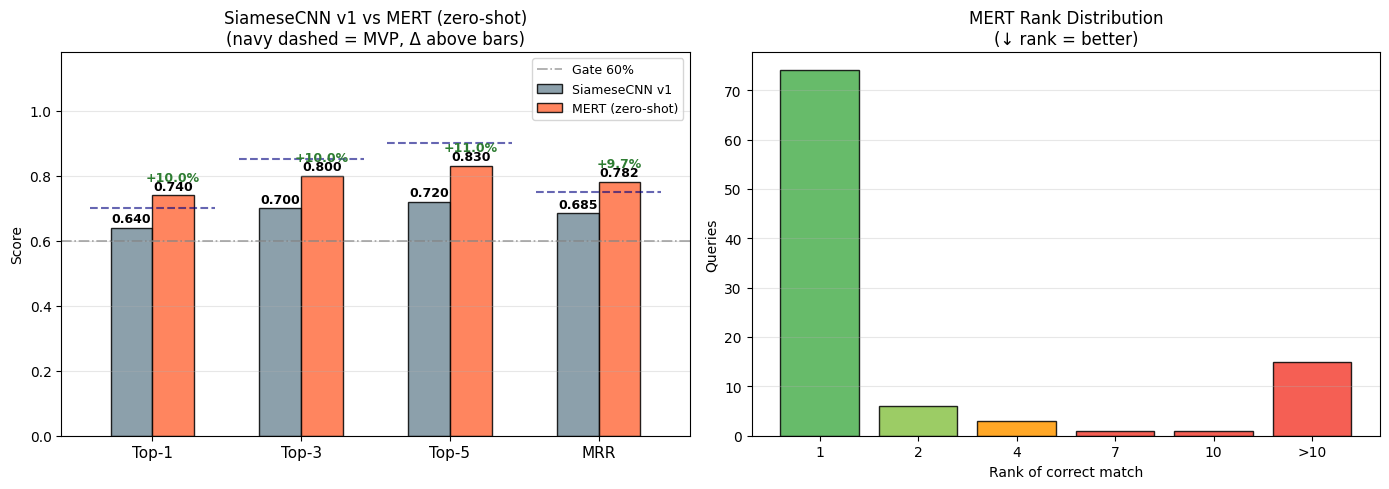

In [ ]:
# Define metrics for evaluation
metric_keys  = ['top1_accuracy', 'top3_accuracy', 'top5_accuracy', 'mrr']
metric_names = ['Top-1', 'Top-3', 'Top-5', 'MRR']
mvp_targets  = [0.70, 0.85, 0.90, 0.75]

v1_vals   = [metrics_v1.get(k, 0) for k in metric_keys]
mert_vals = [metrics_mert.get(k, 0) for k in metric_keys]
deltas    = [m - v for m, v in zip(mert_vals, v1_vals)]

x = np.arange(len(metric_names)); w = 0.28
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bar comparison ──
b1 = axes[0].bar(x - w/2, v1_vals,   w, label='SiameseCNN v1', color='#78909C', alpha=0.85, edgecolor='black')
b2 = axes[0].bar(x + w/2, mert_vals, w, label='MERT (zero-shot)', color='#FF7043', alpha=0.85, edgecolor='black')
for i, (mv, tgt) in enumerate(zip(mvp_targets, mvp_targets)):
    axes[0].plot([i - 1.5*w, i + 1.5*w], [tgt, tgt], 'navy', ls='--', lw=1.5, alpha=0.6)
axes[0].axhline(0.60, color='gray', ls='-.', lw=1.2, alpha=0.7, label='Gate 60%')
for bar, val in [(b, v) for bs, vs in [(b1, v1_vals), (b2, mert_vals)] for b, v in zip(bs, vs)]:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for i, d in enumerate(deltas):
    col = '#2E7D32' if d > 0.005 else '#C62828' if d < -0.005 else 'gray'
    axes[0].text(i + w/2, max(v1_vals[i], mert_vals[i]) + 0.045,
                 f'{d:+.1%}', ha='center', fontsize=9, color=col, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(metric_names, fontsize=11)
axes[0].set_ylim(0, 1.18); axes[0].set_ylabel('Score')
axes[0].set_title('SiameseCNN v1 vs MERT (zero-shot)\n(navy dashed = MVP, Δ above bars)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis='y')

# ── Rank distribution ──
rank_clip = np.clip(rank_pos, 1, 11)
ur, cnt   = np.unique(rank_clip, return_counts=True)
tick_lbl  = [str(r) if r <= 10 else '>10' for r in ur]
rc        = ['#4CAF50' if r == 1 else '#8BC34A' if r <= 3 else
             '#FF9800' if r <= 5 else '#F44336' for r in ur]
axes[1].bar(range(len(ur)), cnt, color=rc, edgecolor='black', alpha=0.85)
axes[1].set_xticks(range(len(ur))); axes[1].set_xticklabels(tick_lbl)
axes[1].set_xlabel('Rank of correct match')
axes[1].set_ylabel('Queries')
axes[1].set_title('MERT Rank Distribution\n(↓ rank = better)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4.8 Per-Composer Breakdown

Composer        N  MERT Top-1   v1 Top-1       Δ   MERT MRR
────────────────────────────────────────────────────────────
Albeniz        12       83.3%      58.3% ▲ +25.0%        0.834
Beethoven      28       46.4%      35.7% ▲ +10.7%        0.503
Chopin         46       91.3%      89.1% ▲ +2.2%        0.957
Debussy         1      100.0%     100.0% = +0.0%        1.000
Liszt           4      100.0%     100.0% = +0.0%        1.000
Mozart          9       44.4%      11.1% ▲ +33.3%        0.563


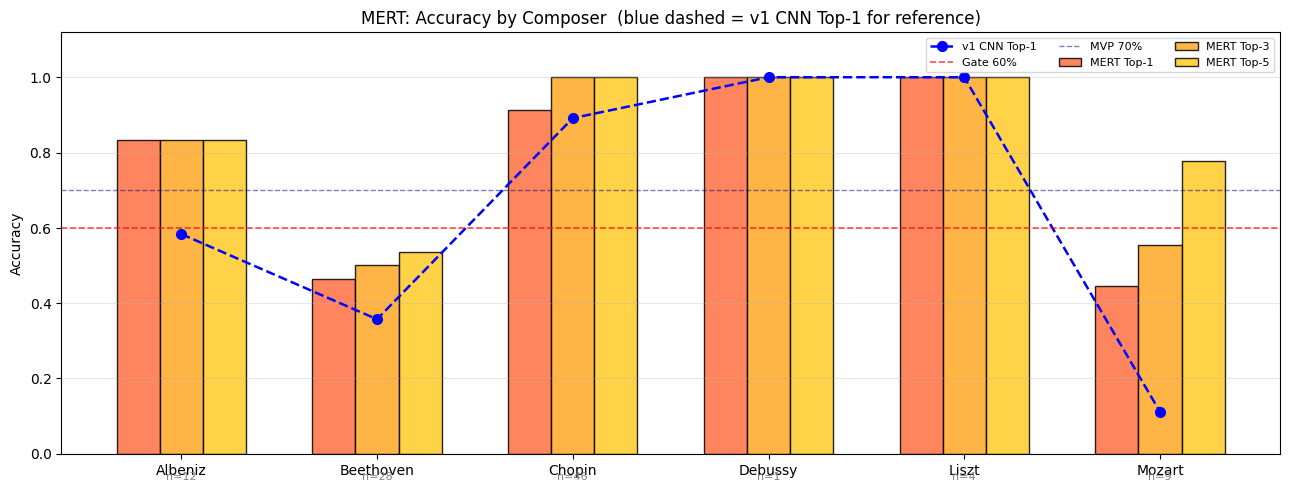

In [ ]:
# Initialize per-composer statistics
comp_stats = defaultdict(lambda: {'correct1': 0, 'correct3': 0, 'correct5': 0,
                                   'rr': [], 'ranks': [], 'n': 0})
# Aggregate per-query results 
for i, meta in enumerate(query_meta):
    c, r = meta['composer'], rank_pos[i]
    comp_stats[c]['n'] += 1
    comp_stats[c]['ranks'].append(r)
    comp_stats[c]['rr'].append(1.0 / r)
    if r <= 1: comp_stats[c]['correct1'] += 1
    if r <= 3: comp_stats[c]['correct3'] += 1
    if r <= 5: comp_stats[c]['correct5'] += 1

# Load v1 per-composer if available
v1_comp = v1_res.get('per_composer', {}) if V1_RESULTS.exists() else {}

composers   = sorted(comp_stats)
mert_top1_c = [comp_stats[c]['correct1'] / comp_stats[c]['n'] for c in composers]
mert_top3_c = [comp_stats[c]['correct3'] / comp_stats[c]['n'] for c in composers]
mert_top5_c = [comp_stats[c]['correct5'] / comp_stats[c]['n'] for c in composers]
comp_n      = [comp_stats[c]['n'] for c in composers]

print(f'{"Composer":<12} {"N":>4} {"MERT Top-1":>11} {"v1 Top-1":>10} {"Δ":>7} {"MERT MRR":>10}')
print('─' * 60)
for c, mt1, n in zip(composers, mert_top1_c, comp_n):
    v1t1   = v1_comp.get(c, {}).get('top1', float('nan'))
    d      = mt1 - v1t1 if not np.isnan(v1t1) else float('nan')
    arrow  = ('▲' if d > 0.005 else '▼' if d < -0.005 else '=') if not np.isnan(d) else '?'
    mrr_c  = np.mean(comp_stats[c]['rr'])
    print(f'{c:<12} {n:>4} {mt1:>11.1%} {v1t1:>10.1%} {arrow} {d:>+5.1%}   {mrr_c:>10.3f}')

x = np.arange(len(composers)); w = 0.22
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w,   mert_top1_c, w, label='MERT Top-1', color='#FF7043', alpha=0.85, edgecolor='black')
ax.bar(x,       mert_top3_c, w, label='MERT Top-3', color='#FFA726', alpha=0.85, edgecolor='black')
ax.bar(x + w,   mert_top5_c, w, label='MERT Top-5', color='#FFCA28', alpha=0.85, edgecolor='black')
if v1_comp:
    v1_top1_c = [v1_comp.get(c, {}).get('top1', 0) for c in composers]
    ax.plot(x, v1_top1_c, 'b--o', ms=7, lw=1.8, label='v1 CNN Top-1')
ax.axhline(0.60, color='red',  ls='--', lw=1.2, alpha=0.7, label='Gate 60%')
ax.axhline(0.70, color='navy', ls='--', lw=1.0, alpha=0.5, label='MVP 70%')
ax.set_xticks(x); ax.set_xticklabels(composers)
ax.set_ylim(0, 1.12); ax.set_ylabel('Accuracy')
ax.set_title('MERT: Accuracy by Composer  (blue dashed = v1 CNN Top-1 for reference)')
ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.3, axis='y')
for i, n in enumerate(comp_n):
    ax.text(i, -0.07, f'n={n}', ha='center', fontsize=8, color='gray')
plt.tight_layout(); plt.show()

## 4.9 Fur Elise — Pitch & Tempo Invariance

Fur Elise variations: 12

Filename                                                   Key  Tempo  Rank     Sim  Hit@1
──────────────────────────────────────────────────────────────────────────────────────────
Fur Elise_Full_K-Amin_T-variable_bothhands.mid            Amin variable     1  0.9836      ✓
FurElise_Intro-2ndVers_K-Amin_T-70_bothhands.mid          Amin     70    66  0.8515      ✗
FurElise_Intro_K-Amin_T-60_righthand.mid                  Amin     60   100  0.8170      ✗
FurElise_Intro_K-Amaj_T-60_righthand.mid                  Amaj     60   103  0.8329      ✗
FurElise_Intro_K-Amin_T-138_righthand_swing.mid           Amin    138   103  0.8198      ✗
FurElise_Intro_K-Cmin_T-60_righthand.mid                  Cmin     60   119  0.7820      ✗
FurElise_Intro_K-Cmaj_T-70_righthand.mid                  Cmaj     70   128  0.8001      ✗
FurElise_2ndVerse_K-Gmin_T-75_righthand.mid               Gmin     75   146  0.6126      ✗
FurElise_2ndVerse_K-Amin_T-60_righthand.mid               Amin

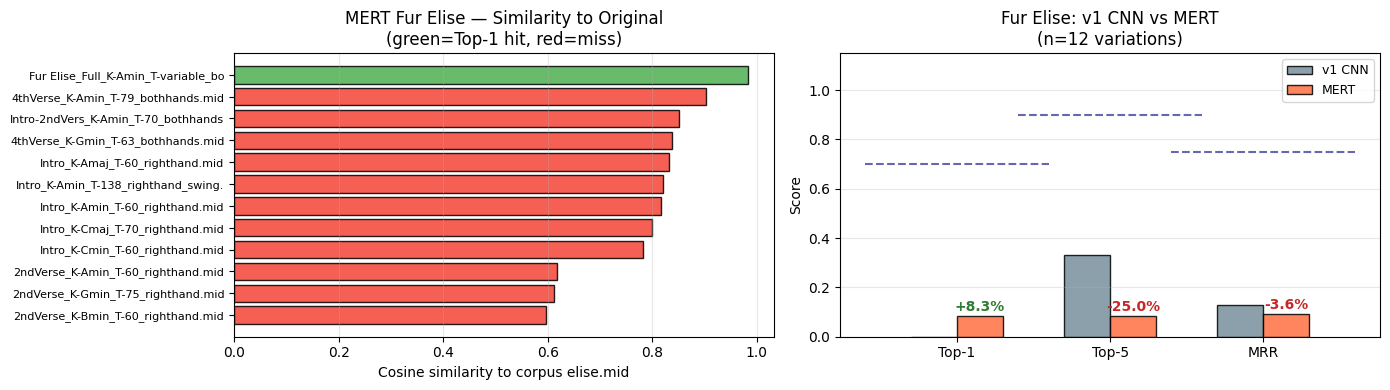

In [ ]:
# Get corpus index for the original "Fur Elise" reference MIDI
elise_idx_c = stem_to_idx['elise.mid']

# Collect Fur Elise evaluation results
elise_rows  = []
for i, meta in enumerate(query_meta):
    if 'elise' not in meta['original'].lower(): continue
    fn   = meta['filename']
    r    = rank_pos[i]
    sim  = float(sim_matrix[i, elise_idx_c].item())
    key  = next((p[2:] for p in fn.replace('.mid','').split('_') if p.startswith('K-')), '?')
    tempo= next((p[2:] for p in fn.replace('.mid','').split('_') if p.startswith('T-')), '?')
    elise_rows.append({'filename': fn, 'key': key, 'tempo': tempo,
                       'rank': r, 'rr': 1.0/r, 'top1': r==1, 'top5': r<=5,
                       'sim_to_orig': sim})

elise_df = pd.DataFrame(elise_rows)

print(f'Fur Elise variations: {len(elise_df)}')
print(f'\n{"Filename":<55} {"Key":>6} {"Tempo":>6} {"Rank":>5} {"Sim":>7} {"Hit@1":>6}')
print('─' * 90)
for _, row in elise_df.sort_values('rank').iterrows():
    hit = '✓' if row['top1'] else '✗'
    print(f'{row["filename"]:<55} {row["key"]:>6} {row["tempo"]:>6} '
          f'{int(row["rank"]):>5} {row["sim_to_orig"]:>7.4f} {hit:>6}')

v1_elise = v1_res.get('fur_elise', {})
print(f'\nFur Elise MERT summary:')
print(f'  Top-1 : {elise_df["top1"].mean():.1%}  (v1: {v1_elise.get("top1", 0):.1%})')
print(f'  Top-5 : {elise_df["top5"].mean():.1%}  (v1: {v1_elise.get("top5", 0.333):.1%})')
print(f'  MRR   : {elise_df["rr"].mean():.3f}  (v1: {v1_elise.get("mrr", 0.127):.3f})')
print(f'\nBy key:')
print(elise_df.groupby('key').agg(
    n=('top1','count'), top1=('top1','mean'),
    mean_sim=('sim_to_orig','mean')).round(3).to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Sim to original, sorted
elise_s = elise_df.sort_values('sim_to_orig', ascending=False)
colors_e = ['#4CAF50' if h else '#F44336' for h in elise_s['top1']]
axes[0].barh(range(len(elise_s)), elise_s['sim_to_orig'],
             color=colors_e, alpha=0.85, edgecolor='black')
axes[0].set_yticks(range(len(elise_s)))
axes[0].set_yticklabels([r['filename'].replace('FurElise_','')[:35] for _, r in elise_s.iterrows()], fontsize=8)
axes[0].set_xlabel('Cosine similarity to corpus elise.mid')
axes[0].set_title('MERT Fur Elise — Similarity to Original\n(green=Top-1 hit, red=miss)')
axes[0].invert_yaxis(); axes[0].grid(True, alpha=0.3, axis='x')

# v1 vs MERT
fur_labels = ['Top-1', 'Top-5', 'MRR']
fur_v1     = [v1_elise.get('top1',0), v1_elise.get('top5',0.333), v1_elise.get('mrr',0.127)]
fur_mert   = [elise_df['top1'].mean(), elise_df['top5'].mean(), elise_df['rr'].mean()]
xf = np.arange(3); wf = 0.3
axes[1].bar(xf - wf/2, fur_v1,  wf, label='v1 CNN', color='#78909C', alpha=0.85, edgecolor='black')
axes[1].bar(xf + wf/2, fur_mert,wf, label='MERT',   color='#FF7043', alpha=0.85, edgecolor='black')
for tgt, xi in zip([0.70,0.90,0.75], range(3)):
    axes[1].plot([xi-2*wf, xi+2*wf],[tgt,tgt],'navy',ls='--',lw=1.5,alpha=0.6)
for i,(v,m) in enumerate(zip(fur_v1, fur_mert)):
    d = m - v
    axes[1].text(i+wf/2, m+0.02, f'{d:+.1%}', ha='center', fontsize=10,
                 color='#2E7D32' if d > 0 else '#C62828', fontweight='bold')
axes[1].set_xticks(xf); axes[1].set_xticklabels(fur_labels)
axes[1].set_ylim(0, 1.15); axes[1].set_ylabel('Score')
axes[1].set_title(f'Fur Elise: v1 CNN vs MERT\n(n={len(elise_df)} variations)')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 4.10 Embedding Space — PCA

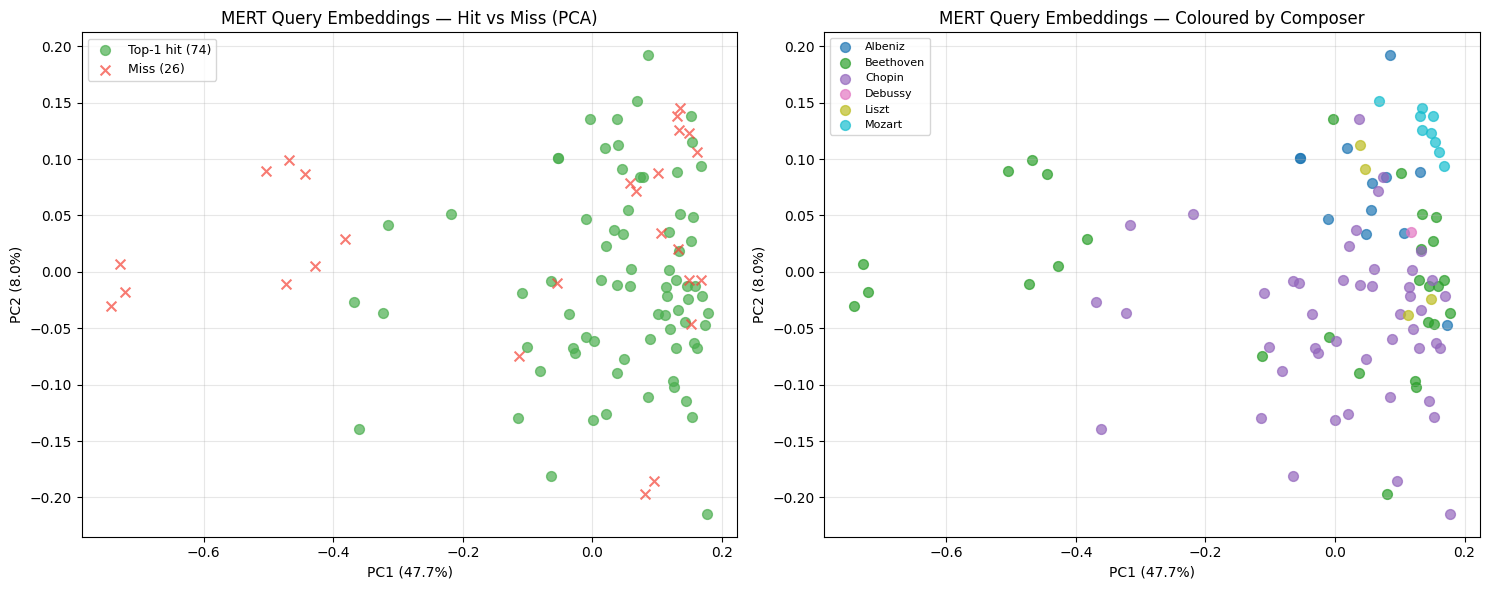

PCA variance explained: 55.6%


In [ ]:
pca = PCA(n_components=2)
q_np = query_matrix.numpy()
q_2d = pca.fit_transform(q_np)

hit_mask = rank_pos == 1

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Hit vs miss
axes[0].scatter(q_2d[hit_mask, 0],  q_2d[hit_mask, 1],
                c='#4CAF50', alpha=0.7, s=50, label=f'Top-1 hit ({hit_mask.sum()})', zorder=3)
axes[0].scatter(q_2d[~hit_mask, 0], q_2d[~hit_mask, 1],
                c='#F44336', alpha=0.7, s=50, marker='x', label=f'Miss ({(~hit_mask).sum()})', zorder=3)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('MERT Query Embeddings — Hit vs Miss (PCA)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Colour by composer
all_comps    = [m['composer'] for m in query_meta]
unique_comps = sorted(set(all_comps))
comp_colors  = plt.cm.tab10(np.linspace(0, 1, len(unique_comps)))
comp_to_col  = dict(zip(unique_comps, comp_colors))
for comp in unique_comps:
    mask_c = np.array([c == comp for c in all_comps])
    axes[1].scatter(q_2d[mask_c, 0], q_2d[mask_c, 1],
                    color=comp_to_col[comp], alpha=0.7, s=50, label=comp)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('MERT Query Embeddings — Coloured by Composer')
axes[1].legend(fontsize=8, loc='best'); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f'PCA variance explained: {pca.explained_variance_ratio_.sum():.1%}')

## 4.11 Failure Analysis

Failures (rank > 5): 17 / 100  (17.0%)
Success  (rank ≤ 5): 83 / 100  (83.0%)


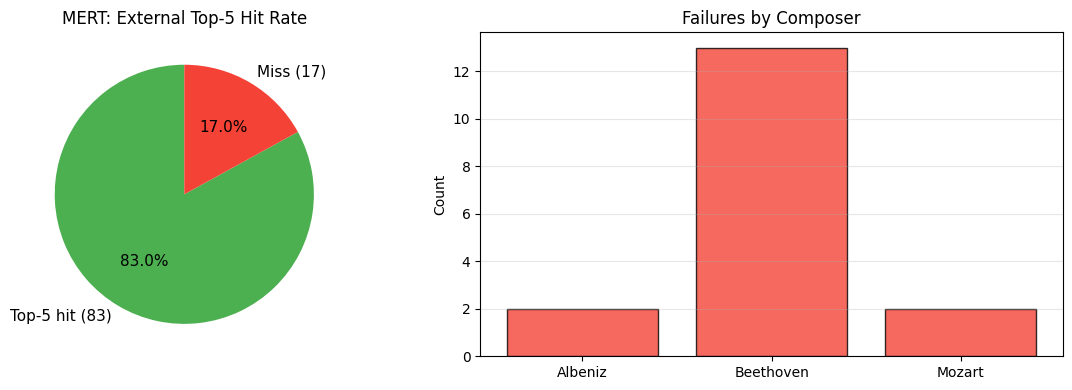


Query                                                            Original  Rank
──────────────────────────────────────────────────────────────────────────────────
Piano Sonata n14 op27  ''Moonlight''.mid                       mond_1.mid     7
  Retrieved top-3: ['schumm-4.mid', 'chpn_op66.mid', 'schub_d960_2.mid']
Piano Sonata n29 Op106 ''Hammerklavier''.mid         beethoven_hammerklavier_1.mid    10
  Retrieved top-3: ['beethoven_hammerklavier_4.mid', 'schub_d760_1.mid', 'islamei.mid']
Piano Sonata n10 K330.mid                                    mz_330_1.mid    16
  Retrieved top-3: ['mz_332_1.mid', 'mz_332_3.mid', 'brahms_opus1_1.mid']
FurElise_Intro-2ndVers_K-Amin_T-70_bothhands.mid                elise.mid    66
  Retrieved top-3: ['scn15_3.mid', 'chpn-p11.mid', 'mz_311_3.mid']
FurElise_Intro_K-Amin_T-60_righthand.mid                        elise.mid   100
  Retrieved top-3: ['haydn_8_4.mid', 'chpn-p11.mid', 'chpn-p7.mid']
FurElise_Intro_K-Amaj_T-60_righthand.mid                 

In [ ]:
# Analyze retrieval failures (rank > 5) to quantify error rate
# visualize failure distribution, and inspect mis-ranked queries
# by composer and top retrieval results
failures  = [(i, meta, per_q[i]) for i, meta in enumerate(query_meta) if rank_pos[i] > 5]
n_fail    = len(failures)

print(f'Failures (rank > 5): {n_fail} / {n_queries}  ({n_fail/n_queries:.1%})')
print(f'Success  (rank ≤ 5): {n_queries - n_fail} / {n_queries}  ({(n_queries-n_fail)/n_queries:.1%})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie([n_queries - n_fail, n_fail],
            labels=[f'Top-5 hit ({n_queries - n_fail})', f'Miss ({n_fail})'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('MERT: External Top-5 Hit Rate')

if failures:
    fail_comp = Counter(m['composer'] for _, m, _ in failures)
    axes[1].bar(fail_comp.keys(), fail_comp.values(),
                color='#F44336', alpha=0.8, edgecolor='black')
    axes[1].set_title('Failures by Composer'); axes[1].set_ylabel('Count')
    axes[1].grid(True, alpha=0.3, axis='y')
else:
    axes[1].text(0.5, 0.5, 'No failures!\nPerfect Top-5',
                 ha='center', va='center', fontsize=14, color='#4CAF50',
                 fontweight='bold', transform=axes[1].transAxes)
    axes[1].axis('off')

plt.tight_layout(); plt.show()

if failures:
    print(f'\n{"Query":<52} {"Original":>20} {"Rank":>5}')
    print('─' * 82)
    for _, meta, res in sorted(failures, key=lambda x: x[2]['rank']):
        print(f'{meta["filename"]:<52} {meta["original"]:>20} {res["rank"]:>5}')
        print(f'  Retrieved top-3: {res["top5"][:3]}')

## 4.12 Save Results

In [ ]:
# JSON result dictionary
results = {
    'model':          'MERT-v1-95M (zero-shot)',
    'mert_model':     MERT_MODEL,
    'max_audio_s':    MAX_AUDIO_S,
    'emb_dim':        EMB_DIM,
    'corpus_size':    len(corpus_files),
    'n_queries':      n_queries,
    'n_skipped':      len(skipped),
    'metrics':        metrics_mert,
    'vs_v1': {
        f'{k}_delta': round(metrics_mert.get(f'top{k}_accuracy', 0) -
                            metrics_v1.get(f'top{k}_accuracy', 0), 4)
        for k in K_VALUES
    },
    'vs_v1_mrr_delta': round(metrics_mert['mrr'] - metrics_v1.get('mrr', 0), 4),
    'per_composer': {
        c: {'n': s['n'],
             'top1': round(s['correct1']/s['n'], 4),
             'top3': round(s['correct3']/s['n'], 4),
             'top5': round(s['correct5']/s['n'], 4),
             'mrr':  round(float(np.mean(s['rr'])), 4),
             'median_rank': int(np.median(s['ranks']))}
        for c, s in comp_stats.items()
    },
    'fur_elise': {
        'n':    len(elise_df),
        'top1': round(float(elise_df['top1'].mean()), 4),
        'top5': round(float(elise_df['top5'].mean()), 4),
        'mrr':  round(float(elise_df['rr'].mean()), 4),
        'keys_found': sorted(elise_df['key'].unique().tolist()),
    },
    'failures_top5': [
        {'query': m['filename'], 'original': m['original'],
         'composer': m['composer'], 'rank': int(rank_pos[qi]),
         'top5_retrieved': per_q[qi]['top5']}
        for qi, m, _ in sorted(failures, key=lambda x: x[2]['rank'])
    ]
}
# Output path
out = CACHE_DIR / 'external_test_results.json'
with open(out, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved → {out.resolve()}  ({out.stat().st_size//1024} KB)')

Saved → /Users/manperumal/Desktop/2026/ML/ai_proj/checkpoints/mert/external_test_results.json  (6 KB)


## 4.13 Zero-Shot Model Evaluation Summary

In [ ]:
# Set thresholds
gate_pass    = metrics_mert['top1_accuracy'] >= 0.60
mvp_pass     = (metrics_mert['top1_accuracy'] >= 0.70 and
                metrics_mert['top3_accuracy'] >= 0.85 and
                metrics_mert['mrr']           >= 0.75)
stretch_pass = (metrics_mert['top1_accuracy'] >= 0.85 and
                metrics_mert['mrr']           >= 0.85)

print('=' * 65)
print('MERT ZERO-SHOT — FINAL SUMMARY')
print('=' * 65)
print(f'\nModel  : {MERT_MODEL}')
print(f'Mode   : Zero-shot (no fine-tuning)')
print(f'Emb dim: {EMB_DIM}  (vs 128 for SiameseCNN)')
print(f'Input  : Audio (MIDI → WAV → 24kHz mono)')
print(f'\nRetrieval metrics (SiameseCNN v1 → MERT):')
for name, k, mvp in zip(metric_names, metric_keys, mvp_targets):
    v1v  = metrics_v1.get(k, 0)
    mv   = metrics_mert.get(k, 0)
    d    = mv - v1v
    arrow= '▲' if d > 0.005 else '▼' if d < -0.005 else '='
    status = '✓' if mv >= mvp else '✗'
    print(f'  {name:<6}: {v1v:.4f} → {mv:.4f}  ({d:+.4f} {arrow})  mvp≥{mvp:.0%} {status}')
print(f'\nFur Elise (pitch/tempo robustness):')
print(f'  Top-1: {results["fur_elise"]["top1"]:.1%}  (v1: {v1_elise.get("top1",0):.1%})')
print(f'  Top-5: {results["fur_elise"]["top5"]:.1%}  (v1: {v1_elise.get("top5",0.333):.1%})')
print(f'  MRR  : {results["fur_elise"]["mrr"]:.3f}  (v1: {v1_elise.get("mrr",0.127):.3f})')
print(f'\nBest composer : {max(comp_stats, key=lambda c: comp_stats[c]["correct1"]/comp_stats[c]["n"])}')
print(f'Worst composer: {min(comp_stats, key=lambda c: comp_stats[c]["correct1"]/comp_stats[c]["n"])}')
print(f'\nSuccess criteria:')
print(f'  Gate   (Top-1≥60%)                   : {"PASSED ✓" if gate_pass    else "FAILED ✗"}')
print(f'  MVP    (Top-1≥70%, Top-3≥85%, MRR≥75%): {"PASSED ✓" if mvp_pass    else "FAILED ✗"}')
print(f'  Stretch(Top-1≥85%, MRR≥85%)          : {"PASSED ✓" if stretch_pass else "FAILED ✗"}')
print('=' * 65)

MERT ZERO-SHOT — FINAL SUMMARY

Model  : m-a-p/MERT-v1-95M
Mode   : Zero-shot (no fine-tuning)
Emb dim: 768  (vs 128 for SiameseCNN)
Input  : Audio (MIDI → WAV → 24kHz mono)

Retrieval metrics (SiameseCNN v1 → MERT):
  Top-1 : 0.6400 → 0.7400  (+0.1000 ▲)  mvp≥70% ✓
  Top-3 : 0.7000 → 0.8000  (+0.1000 ▲)  mvp≥85% ✗
  Top-5 : 0.7200 → 0.8300  (+0.1100 ▲)  mvp≥90% ✗
  MRR   : 0.6846 → 0.7816  (+0.0970 ▲)  mvp≥75% ✓

Fur Elise (pitch/tempo robustness):
  Top-1: 8.3%  (v1: 0.0%)
  Top-5: 8.3%  (v1: 33.3%)
  MRR  : 0.091  (v1: 0.127)

Best composer : Debussy
Worst composer: Mozart

Success criteria:
  Gate   (Top-1≥60%)                   : PASSED ✓
  MVP    (Top-1≥70%, Top-3≥85%, MRR≥75%): FAILED ✗
  Stretch(Top-1≥85%, MRR≥85%)          : FAILED ✗


# 5. MERT Fine-Tuning with LoRA: Composer Similarity
### COLAB_MERT_Finetune_v5.ipynb

Fine-tunes `m-a-p/MERT-v1-95M` using LoRA adapters on all attention projections.
No projection head — the 768-dim L2-normalized MERT output is used directly with TripletMarginLoss.

## Sections
- **5.0** — Setup (install deps, mount Drive, config)
- **5.1** — Triplet CSV generation (always regenerated)
- **5.2** — Train/val split (skips if Drive files exist)
- **5.3** — LoRA training (intra-epoch checkpointing every N steps)
- **5.4** — Evaluation

**Resume after disconnect:** Run all cells top-to-bottom. Each section checks Drive for its checkpoint and skips if already done. Training resumes from the last saved step.

In [1]:
# ── Config ────────────────────────────────────────────────────────────────────
DRIVE_BASE   = "/content/drive/MyDrive/AAI-590 Capstone/checkpoints5"
CHUNK_PATH   = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/ChunkSamples"
MODEL_NAME       = "m-a-p/MERT-v1-95M"
MODEL_CACHE_DIR  = "/content/drive/MyDrive/AAI-590 Capstone/checkpoints5/model_cache"
SR           = 24000
LORA_R       = 8
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05
LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj"]
MARGIN       = 0.3
CNN_FILTERS  = 256           # filters per scale in CNN temporal encoder
CNN_KERNELS  = (3, 5, 7)     # multi-scale kernel sizes (frames)
EMBED_DIM    = 128           # final embedding dimension
BATCH_SIZE   = 8        # each triplet = 3 WAV forward passes through MERT
LR           = 5e-5
EPOCHS       = 10
SAVE_STEPS   = 1        # save full checkpoint to Drive after every optimizer step
GRAD_CLIP    = 1.0      # gradient clipping max norm (0 = disabled)
SEED         = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Create Drive subdirectories
for sub in ["splits", "checkpoints/lora_best", "checkpoints/lora_last", "results", "model_cache"]:
    os.makedirs(os.path.join(DRIVE_BASE, sub), exist_ok=True)
print("Drive folders ready.")

Mounted at /content/drive
Device: cuda
Drive folders ready.


In [2]:
CHUNK_PATH   = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/ChunkSamples"
TRIPLET_CSV = os.path.join(DRIVE_BASE, "triplet_df.csv")

## 5.1 — Triplet CSV Generation
Regenerates (anchor, positive, negative) DataFrame from ChunkSamples and saves to Drive.

Always re-runs (~30 seconds). Anchor = first chunk of each song; positives = remaining chunks;

negative = chunks from a randomly chosen different composer.

In [ ]:
# ── 5.1: Triplet CSV ──────────────────
TRIPLET_CSV = os.path.join(DRIVE_BASE, "triplet_df.csv")

def numeric_sort(f):
    match = re.search(r'_chunk_(\d+)\.wav$', f)
    return int(match.group(1)) if match else -1

data = []
used_negatives = set()

for composer in os.listdir(CHUNK_PATH):
    composer_path = os.path.join(CHUNK_PATH, composer)
    if not os.path.isdir(composer_path):
        continue
    for song in os.listdir(composer_path):
        song_path = os.path.join(composer_path, song)
        if not os.path.isdir(song_path):
            continue
        chunks = sorted(
            [f for f in os.listdir(song_path) if f.endswith(".wav")],
            key=numeric_sort
        )
        if len(chunks) < 2:
            continue
        anchor    = chunks[0]
        positives = chunks[1:]
        other_composers = [
            c for c in os.listdir(CHUNK_PATH)
            if c != composer and os.path.isdir(os.path.join(CHUNK_PATH, c))
        ]
        if not other_composers:
            continue
        chosen_composer      = random.choice(other_composers)
        chosen_composer_path = os.path.join(CHUNK_PATH, chosen_composer)
        negative_pool = []
        for other_song in sorted(os.listdir(chosen_composer_path)):
            other_song_path = os.path.join(chosen_composer_path, other_song)
            if not os.path.isdir(other_song_path):
                continue
            for f in sorted(os.listdir(other_song_path), key=numeric_sort):
                if f.endswith(".wav") and f not in used_negatives:
                    negative_pool.append(f)
        min_len = min(len(positives), len(negative_pool))
        for i in range(min_len):
            data.append({
                "anchor":   anchor,
                "positive": positives[i],
                "negative": negative_pool[i],
                "composer": composer,
                "song":     song,
            })
            used_negatives.add(negative_pool[i])

In [3]:
# Show triplet dataset
df = pd.read_csv(TRIPLET_CSV)
print(f"Triplet CSV saved → {TRIPLET_CSV}")
print(f"Total triplets: {len(df)}")
print(df.head())

Triplet CSV saved → /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/triplet_df.csv
Total triplets: 23183
                 anchor              positive             negative composer  \
0  bach_847_chunk_1.wav  bach_847_chunk_2.wav  islamei_chunk_1.wav     bach   
1  bach_847_chunk_1.wav  bach_847_chunk_3.wav  islamei_chunk_2.wav     bach   
2  bach_847_chunk_1.wav  bach_847_chunk_4.wav  islamei_chunk_3.wav     bach   
3  bach_847_chunk_1.wav  bach_847_chunk_5.wav  islamei_chunk_4.wav     bach   
4  bach_847_chunk_1.wav  bach_847_chunk_6.wav  islamei_chunk_5.wav     bach   

       song  
0  bach_847  
1  bach_847  
2  bach_847  
3  bach_847  
4  bach_847  


## 5.2 — Train/Val Split
80/20 stratified split on composer. Skips if Drive files already exist.

In [5]:
# ── 5.2: Train/val split ──────────────────
TRAIN_IDX_PATH = os.path.join(DRIVE_BASE, "splits", "train_idx.npy")
VAL_IDX_PATH   = os.path.join(DRIVE_BASE, "splits",   "val_idx.npy")

if os.path.exists(TRAIN_IDX_PATH) and os.path.exists(VAL_IDX_PATH):
    train_idx = np.load(TRAIN_IDX_PATH)
    val_idx   = np.load(VAL_IDX_PATH)
    print(f"Loaded split from Drive. Train: {len(train_idx)}  Val: {len(val_idx)}")
else:
    all_idx = np.arange(len(df))
    train_idx, val_idx = train_test_split(
        all_idx,
        test_size=0.2,
        random_state=SEED,
        stratify=df["composer"].values
    )
    np.save(TRAIN_IDX_PATH, train_idx)
    np.save(VAL_IDX_PATH,   val_idx)
    print(f"Split saved to Drive. Train: {len(train_idx)}  Val: {len(val_idx)}")

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)
print(f"train_df: {len(train_df)} rows  val_df: {len(val_df)} rows")

Loaded split from Drive. Train: 18546  Val: 4637
train_df: 18546 rows  val_df: 4637 rows


## 5.3 — LoRA Training

### Architecture
```
MERT-v1-95M
  + LoRA adapters on q_proj, k_proj, v_proj, o_proj (all transformer layers)
  → mean-pool last_hidden_state → 768-dim
  → L2-normalize → 768-dim unit-sphere embedding
Loss: TripletMarginLoss(margin=0.3)
```

### Resume behaviour
Training state is saved every `SAVE_STEPS` optimizer steps to Drive (`training_state.json`).
On resume, the LoRA adapter and optimizer are reloaded and the loop skips already-completed batches.

In [7]:
# ── 5.3A: Dataset + Model setup ────────────────────────────────────────

# Build filename → full path lookup
file_lookup = {}
for composer in os.listdir(CHUNK_PATH):
    cp = os.path.join(CHUNK_PATH, composer)
    if not os.path.isdir(cp):
        continue
    for song in os.listdir(cp):
        sp = os.path.join(cp, song)
        if not os.path.isdir(sp):
            continue
        for f in os.listdir(sp):
            if f.endswith(".wav"):
                file_lookup[f] = os.path.join(sp, f)
print(f"File lookup built: {len(file_lookup)} files")


class TripletWAVDataset(Dataset):
    """Loads WAV triplets on-the-fly from filenames."""
    def __init__(self, dataframe, file_lookup, processor, sr=24000):
        self.df          = dataframe.reset_index(drop=True)
        self.file_lookup = file_lookup
        self.processor   = processor
        self.sr          = sr

    def __len__(self):
        return len(self.df)

    def _load(self, fname):
        path  = self.file_lookup.get(fname)
        audio, _ = librosa.load(path, sr=self.sr)
        inputs   = self.processor(audio, sampling_rate=self.sr, return_tensors="pt")
        # squeeze batch dim added by processor
        return {k: v.squeeze(0) for k, v in inputs.items()}

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return (
            self._load(row["anchor"]),
            self._load(row["positive"]),
            self._load(row["negative"]),
        )


def collate_triplets(batch):
    """Stack variable-length inputs by padding to the longest in the batch."""
    anchors, positives, negatives = zip(*batch)

    def stack(items):
        # items is a list of dicts; pad input_values to same length
        max_len = max(x["input_values"].shape[-1] for x in items)
        padded  = []
        for x in items:
            iv = x["input_values"]  # (seq_len,)
            pad_len = max_len - iv.shape[-1]
            padded.append(F.pad(iv, (0, pad_len)))
        return {"input_values": torch.stack(padded)}

    return stack(anchors), stack(positives), stack(negatives)


# ── Load processor + base model (Drive cache → HuggingFace fallback) ────────
if os.path.isdir(MODEL_CACHE_DIR) and os.listdir(MODEL_CACHE_DIR):
    print(f"Loading MERT from Drive cache: {MODEL_CACHE_DIR}")
    processor  = AutoProcessor.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
    base_model = AutoModel.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
else:
    print("Drive cache not found. Downloading from HuggingFace...")
    processor  = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)
    base_model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True)
    processor.save_pretrained(MODEL_CACHE_DIR)
    base_model.save_pretrained(MODEL_CACHE_DIR)
    print(f"Model cached to Drive: {MODEL_CACHE_DIR}")


# ── CNN Temporal Projection Head ────────────────────────────────────────────
class CNNProjectionHead(nn.Module):
    """
    Replaces mean-pooling with learned multi-scale temporal aggregation.

    Input : last_hidden_state  (batch, seq_len, 768)
    Output: L2-normalised embedding  (batch, EMBED_DIM)

    Three parallel Conv1d streams with different kernel sizes capture
    local (3-frame), mid (5-frame) and broader (7-frame) temporal patterns.
    Their global-average-pooled outputs are concatenated, then projected
    to EMBED_DIM via a two-layer MLP with LayerNorm + GELU.
    """
    def __init__(self, input_dim=768, num_filters=256,
                 kernel_sizes=(3, 5, 7), embed_dim=128, dropout=0.1):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(input_dim, num_filters, k, padding=k // 2),
                nn.BatchNorm1d(num_filters),
                nn.GELU(),
            )
            for k in kernel_sizes
        ])
        fused = num_filters * len(kernel_sizes)
        self.proj = nn.Sequential(
            nn.Linear(fused, fused // 2),
            nn.LayerNorm(fused // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fused // 2, embed_dim),
        )

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        # hidden_states: (batch, seq_len, 768)
        x = hidden_states.transpose(1, 2)           # → (batch, 768, seq_len)
        pooled = [conv(x).mean(dim=2) for conv in self.convs]
        x = torch.cat(pooled, dim=1)                # (batch, num_filters * n_kernels)
        return F.normalize(self.proj(x), p=2, dim=1)  # (batch, embed_dim)


# Apply LoRA
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGETS,
    lora_dropout=LORA_DROPOUT,
    bias="none",
)
model = get_peft_model(base_model, lora_config)
model.to(DEVICE)
model.print_trainable_parameters()

# Instantiate CNN projection head
cnn_head = CNNProjectionHead(
    input_dim    = 768,
    num_filters  = CNN_FILTERS,
    kernel_sizes = CNN_KERNELS,
    embed_dim    = EMBED_DIM,
    dropout      = 0.1,
).to(DEVICE)
cnn_params = sum(p.numel() for p in cnn_head.parameters())
print(f"CNN projection head: {cnn_params:,} params  (filters={CNN_FILTERS}, kernels={CNN_KERNELS}, embed={EMBED_DIM})")

# DataLoaders
train_dataset = TripletWAVDataset(train_df, file_lookup, processor, SR)
val_dataset   = TripletWAVDataset(val_df,   file_lookup, processor, SR)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_triplets, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_triplets, num_workers=2, pin_memory=True
)

criterion = torch.nn.TripletMarginLoss(margin=MARGIN, p=2)
optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(cnn_head.parameters()), lr=LR
)
total_steps = EPOCHS * len(train_loader)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")
print(f"Total training steps: {total_steps}")

# ── Mixed-precision (AMP) setup ──────────────────────────────────────────────
use_amp = DEVICE.type == "cuda"
scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)
print(f"Mixed precision (AMP): {use_amp}")


File lookup built: 43663 files
Loading MERT from Drive cache: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/model_cache


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

trainable params: 442,368 || all params: 94,814,080 || trainable%: 0.4666
CNN projection head: 3,296,768 params  (filters=256, kernels=(3, 5, 7), embed=128)
Train batches: 2319  Val batches: 580
Total training steps: 23190
Mixed precision (AMP): True


/tmp/ipykernel_6588/18749039.py:167: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)


In [8]:
# ── Section 3B: Training loop ─────────────────────────────────────────────────
LORA_BEST_DIR  = os.path.join(DRIVE_BASE, "checkpoints", "lora_best")
LORA_LAST_DIR  = os.path.join(DRIVE_BASE, "checkpoints", "lora_last")
CNN_BEST_PATH  = os.path.join(DRIVE_BASE, "checkpoints", "cnn_head_best.pt")
CNN_LAST_PATH  = os.path.join(DRIVE_BASE, "checkpoints", "cnn_head_last.pt")
OPT_STATE_PATH = os.path.join(DRIVE_BASE, "checkpoints", "optimizer_state.pt")
TRAIN_STATE    = os.path.join(DRIVE_BASE, "checkpoints", "training_state.json")
LOG_PATH       = os.path.join(DRIVE_BASE, "training_log.csv")


def get_embedding(model, batch_inputs):
    """Forward through LoRA-MERT → CNN projection head → L2-normed EMBED_DIM embedding."""
    inputs = {k: v.to(DEVICE) for k, v in batch_inputs.items()}
    outputs = model(**inputs)
    hidden = outputs.last_hidden_state      # (batch, seq_len, 768)
    return cnn_head(hidden)                 # (batch, EMBED_DIM) L2-normed


In [9]:
# ── Resume ───────────────────
start_epoch   = 0
resume_step   = 0       # steps already completed inside start_epoch
global_step   = 0
best_val_loss = float("inf")
training_log  = []

if os.path.exists(TRAIN_STATE):
    with open(TRAIN_STATE) as f:
        state = json.load(f)
    start_epoch   = state["epoch"]
    resume_step   = state["step"]       # batches done in start_epoch
    global_step   = state["global_step"]
    best_val_loss = state["best_val_loss"]
    # Load a fresh base model so PeftModel.from_pretrained has no stale
    # peft_config attached — avoids the "Already found peft_config" warning
    # and guarantees the new optimizer points at the correct parameters.
    opt_ckpt = torch.load(OPT_STATE_PATH, map_location=DEVICE)
    fresh_base = AutoModel.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
    model = PeftModel.from_pretrained(fresh_base, LORA_LAST_DIR)
    model.to(DEVICE)
    if os.path.exists(CNN_LAST_PATH):
        cnn_head.load_state_dict(torch.load(CNN_LAST_PATH, map_location=DEVICE))
    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(cnn_head.parameters()), lr=LR
    )
    optimizer.load_state_dict(opt_ckpt["optimizer"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    scheduler.load_state_dict(opt_ckpt["scheduler"])
    if "scaler" in opt_ckpt:
        scaler.load_state_dict(opt_ckpt["scaler"])
    print(f"Resumed: epoch={start_epoch} step={resume_step} global_step={global_step}")
else:
    print("No checkpoint found. Training from scratch.")

if os.path.exists(LOG_PATH):
    training_log = pd.read_csv(LOG_PATH).to_dict(orient="records")


def save_checkpoint(is_best=False, end_of_epoch=False):
    """Save LoRA adapter + optimizer/scheduler/scaler state to Drive.
    end_of_epoch=True advances epoch/step so resume skips no batches.
    """
    model.save_pretrained(LORA_LAST_DIR)
    torch.save(cnn_head.state_dict(), CNN_LAST_PATH)
    torch.save({
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler":    scaler.state_dict(),
    }, OPT_STATE_PATH)
    with open(TRAIN_STATE, "w") as f:
        json.dump({
            "epoch":         epoch + 1 if end_of_epoch else epoch,
            "step":          0         if end_of_epoch else batch_idx + 1,
            "global_step":   global_step,
            "best_val_loss": best_val_loss,
        }, f)
    if is_best:
        model.save_pretrained(LORA_BEST_DIR)
        torch.save(cnn_head.state_dict(), CNN_BEST_PATH)


# ── Training ──────────────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS):
    model.train()
    cnn_head.train()
    train_loss_total = 0.0
    train_batches    = 0

    for batch_idx, (a_in, p_in, n_in) in enumerate(
        tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]")
    ):
        # Skip already-completed batches on resume
        if epoch == start_epoch and batch_idx < resume_step:
            scheduler.step()
            global_step += 1
            continue

        with torch.cuda.amp.autocast(enabled=use_amp):
            a_emb = get_embedding(model, a_in)
            p_emb = get_embedding(model, p_in)
            n_emb = get_embedding(model, n_in)
            loss  = criterion(a_emb, p_emb, n_emb)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        if GRAD_CLIP > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                list(model.parameters()) + list(cnn_head.parameters()), GRAD_CLIP
            )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_loss_total += loss.item()
        train_batches    += 1
        global_step      += 1

        # Intra-epoch checkpoint
        if global_step % SAVE_STEPS == 0:
            save_checkpoint(is_best=False)

    avg_train_loss = train_loss_total / max(train_batches, 1)

    # ── Validation ────────────────────────────────────────────────────────────
    model.eval()
    cnn_head.eval()
    val_loss_total = 0.0
    val_pos_sim    = 0.0
    val_neg_sim    = 0.0

    with torch.no_grad():
        for a_in, p_in, n_in in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [val]"):
            with torch.cuda.amp.autocast(enabled=use_amp):
                a_emb = get_embedding(model, a_in)
                p_emb = get_embedding(model, p_in)
                n_emb = get_embedding(model, n_in)
                loss  = criterion(a_emb, p_emb, n_emb)
            val_loss_total += loss.item()
            val_pos_sim += F.cosine_similarity(a_emb, p_emb).mean().item()
            val_neg_sim += F.cosine_similarity(a_emb, n_emb).mean().item()

    avg_val_loss = val_loss_total / len(val_loader)
    avg_pos_sim  = val_pos_sim   / len(val_loader)
    avg_neg_sim  = val_neg_sim   / len(val_loader)

    # ── Log ───────────────────────────────────────────────────────────────────
    is_best = avg_val_loss < best_val_loss
    if is_best:
        best_val_loss = avg_val_loss

    row = {
        "epoch":       epoch + 1,
        "global_step": global_step,
        "train_loss":  round(avg_train_loss, 6),
        "val_loss":    round(avg_val_loss,   6),
        "val_pos_sim": round(avg_pos_sim,    4),
        "val_neg_sim": round(avg_neg_sim,    4),
        "val_gap":     round(avg_pos_sim - avg_neg_sim, 4),
        "lr":          optimizer.param_groups[0]["lr"],
        "best":        is_best,
    }
    training_log.append(row)
    pd.DataFrame(training_log).to_csv(LOG_PATH, index=False)

    # Save end-of-epoch checkpoint (and best if improved)
    save_checkpoint(is_best=is_best, end_of_epoch=True)
    resume_step = 0   # next epoch starts from batch 0

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={avg_train_loss:.4f} val_loss={avg_val_loss:.4f} "
        f"pos_sim={avg_pos_sim:.4f} neg_sim={avg_neg_sim:.4f} "
        f"gap={avg_pos_sim - avg_neg_sim:.4f}"
        + ("  ✓ best" if is_best else "")
    )

print(f"\nTraining complete. Best val_loss={best_val_loss:.4f}")
print(f"Best LoRA adapter → {LORA_BEST_DIR}")

No checkpoint found. Training from scratch.


Epoch 1/10 [train]:   0%|          | 0/2319 [00:00<?, ?it/s]/tmp/ipykernel_6588/1951960872.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/10 [val]:   0%|          | 0/580 [00:00<?, ?it/s]/tmp/ipykernel_6588/1951960872.py:115: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/10 [val]: 100%|██████████| 580/580 [20:01<00:00,  2.07s/it]


Epoch 01 | train_loss=0.0993 val_loss=0.0950 pos_sim=0.5630 neg_sim=0.0784 gap=0.4846  ✓ best


Epoch 2/10 [val]: 100%|██████████| 580/580 [00:38<00:00, 15.20it/s]


Epoch 02 | train_loss=0.0560 val_loss=0.0628 pos_sim=0.5149 neg_sim=-0.0997 gap=0.6145  ✓ best


...

Epoch 08 | train_loss=0.0125 val_loss=0.0404 pos_sim=0.5475 neg_sim=-0.0514 gap=0.5989


Epoch 9/10 [val]: 100%|██████████| 580/580 [00:38<00:00, 15.21it/s]


Epoch 09 | train_loss=0.0110 val_loss=0.0302 pos_sim=0.5196 neg_sim=-0.1301 gap=0.6497  ✓ best


Epoch 10/10 [val]: 100%|██████████| 580/580 [00:38<00:00, 15.03it/s]

Epoch 10 | train_loss=0.0102 val_loss=0.0320 pos_sim=0.5208 neg_sim=-0.1277 gap=0.6486

Training complete. Best val_loss=0.0302
Best LoRA adapter → /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/checkpoints/lora_best


## 5.4 — Evaluation
Loads the best LoRA adapter and computes cosine similarity distributions on the val set.
Saves results and a 2-panel histogram to Drive.

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Best LoRA adapter loaded from /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/checkpoints/lora_best
Best CNN head loaded  from /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/checkpoints/cnn_head_best.pt


Evaluating:   0%|          | 0/580 [00:00<?, ?it/s]/tmp/ipykernel_6588/896868102.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Evaluating: 100%|██████████| 580/580 [00:37<00:00, 15.58it/s]


finetune_pos_mean  0.5196
finetune_neg_mean -0.1300
finetune_gap       0.6496
finetune_pos_std   0.2693
finetune_neg_std   0.2963


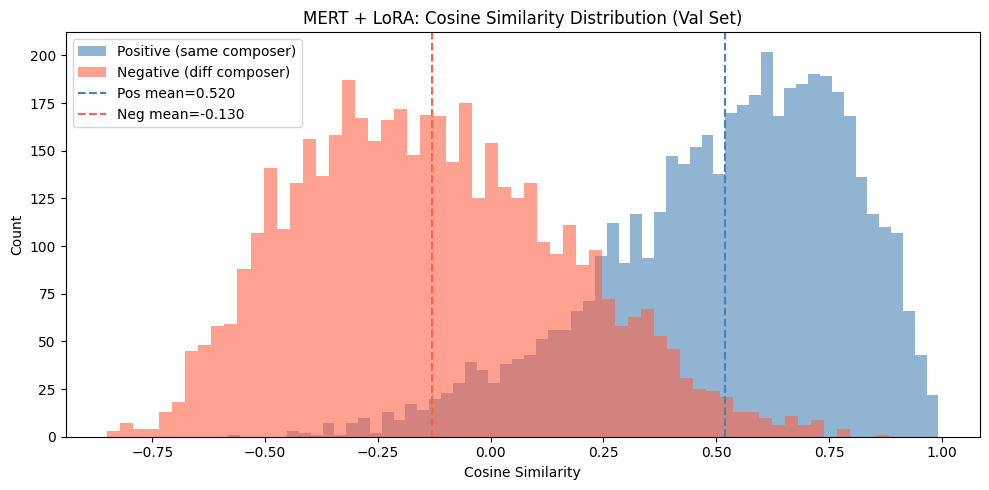

Plot saved → /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/score_plot.png
Eval results saved → /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/eval_results.csv


In [10]:
# ── Section 4: Evaluation ─────────────────────────────────────────────────────
EVAL_CSV  = os.path.join(DRIVE_BASE, "results", "eval_results.csv")
PLOT_PATH = os.path.join(DRIVE_BASE, "results", "score_plot.png")

# Load best LoRA adapter + CNN projection head
eval_base  = AutoModel.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
eval_model = PeftModel.from_pretrained(eval_base, LORA_BEST_DIR)
eval_model.to(DEVICE)
eval_model.eval()
cnn_head.load_state_dict(torch.load(CNN_BEST_PATH, map_location=DEVICE))
cnn_head.eval()
print(f"Best LoRA adapter loaded from {LORA_BEST_DIR}")
print(f"Best CNN head loaded  from {CNN_BEST_PATH}")

# ── Compute fine-tuned cosine similarities on val set ─────────────────────────
ft_pos_sims, ft_neg_sims = [], []

with torch.no_grad():
    for a_in, p_in, n_in in tqdm(val_loader, desc="Evaluating"):
        with torch.cuda.amp.autocast(enabled=use_amp):
            a_emb = get_embedding(eval_model, a_in)
            p_emb = get_embedding(eval_model, p_in)
            n_emb = get_embedding(eval_model, n_in)
        ft_pos_sims.append(F.cosine_similarity(a_emb, p_emb).cpu().numpy())
        ft_neg_sims.append(F.cosine_similarity(a_emb, n_emb).cpu().numpy())

ft_pos_sim = np.concatenate(ft_pos_sims)
ft_neg_sim = np.concatenate(ft_neg_sims)

# ── Summary table ─────────────────────────────────────────────────────────────
results = {
    "finetune_pos_mean": round(float(ft_pos_sim.mean()), 4),
    "finetune_neg_mean": round(float(ft_neg_sim.mean()), 4),
    "finetune_gap":      round(float(ft_pos_sim.mean() - ft_neg_sim.mean()), 4),
    "finetune_pos_std":  round(float(ft_pos_sim.std()),  4),
    "finetune_neg_std":  round(float(ft_neg_sim.std()),  4),
}
results_df = pd.DataFrame([results])
results_df.to_csv(EVAL_CSV, index=False)
print(results_df.T.to_string(header=False))

# ── Distribution plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ft_pos_sim, bins=60, alpha=0.6, label="Positive (same composer)", color="steelblue")
ax.hist(ft_neg_sim, bins=60, alpha=0.6, label="Negative (diff composer)", color="tomato")
ax.axvline(ft_pos_sim.mean(), color="steelblue", linestyle="--", linewidth=1.5,
           label=f"Pos mean={ft_pos_sim.mean():.3f}")
ax.axvline(ft_neg_sim.mean(), color="tomato",    linestyle="--", linewidth=1.5,
           label=f"Neg mean={ft_neg_sim.mean():.3f}")
ax.set_title("MERT + LoRA: Cosine Similarity Distribution (Val Set)")
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150)
plt.show()
print(f"Plot saved → {PLOT_PATH}")
print(f"Eval results saved → {EVAL_CSV}")

## 5.5 — Extract All Embeddings
Extracts embeddings for all chunks in the dataset using the best fine-tuned model and saves them to a DataFrame.

In [12]:
# ── Section 5: Extract All Embeddings ─────────────────────────────────────────
all_files = list(file_lookup.keys())

class AllChunksDataset(Dataset):
    """Dataset for extracting embeddings from all chunks."""
    def __init__(self, file_list, file_lookup, processor, sr=24000):
        self.file_list   = file_list
        self.file_lookup = file_lookup
        self.processor   = processor
        self.sr          = sr

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fname = self.file_list[idx]
        path  = self.file_lookup[fname]
        audio, _ = librosa.load(path, sr=self.sr)
        inputs   = self.processor(audio, sampling_rate=self.sr, return_tensors="pt")
        return fname, {k: v.squeeze(0) for k, v in inputs.items()}

def collate_all_chunks(batch):
    fnames, items = zip(*batch)
    max_len = max(x["input_values"].shape[-1] for x in items)
    padded  = []
    for x in items:
        iv = x["input_values"]
        pad_len = max_len - iv.shape[-1]
        padded.append(F.pad(iv, (0, pad_len)))
    return fnames, {"input_values": torch.stack(padded)}

all_dataset = AllChunksDataset(all_files, file_lookup, processor, SR)
all_loader  = DataLoader(
    all_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_all_chunks, num_workers=2, pin_memory=True
)

results_data = []
eval_model.eval()
cnn_head.eval()

with torch.no_grad():
    for fnames, batch_inputs in tqdm(all_loader, desc="Extracting all embeddings"):
        with torch.amp.autocast('cuda', enabled=use_amp):
            embs = get_embedding(eval_model, batch_inputs)
        embs_np = embs.cpu().numpy()

        for fname, emb in zip(fnames, embs_np):
            chunk_match = re.search(r'_chunk_(\d+)\.wav$', fname)
            chunk_num = int(chunk_match.group(1)) if chunk_match else -1
            results_data.append({
                "filename": fname,
                "chunk": chunk_num,
                "embeddings": emb
            })

all_embeddings_df = pd.DataFrame(results_data)

# Save to pickle to preserve numpy arrays naturally
EMBEDDINGS_PATH = os.path.join(DRIVE_BASE, "results", "all_embeddings.pkl")
all_embeddings_df.to_pickle(EMBEDDINGS_PATH)

print(f"\nSaved {len(all_embeddings_df)} embeddings to {EMBEDDINGS_PATH}")
display(all_embeddings_df.head())

Extracting all embeddings: 100%|██████████| 5458/5458 [35:09<00:00,  2.59it/s]



Saved 43663 embeddings to /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/all_embeddings.pkl


,filename,chunk,embeddings
0,bach_847_chunk_1.wav,1,"[0.05016434, 0.069372244, -0.009370848, 0.0846..."
1,bach_847_chunk_2.wav,2,"[0.049578503, 0.091372475, 0.0034356404, 0.139..."
2,bach_847_chunk_3.wav,3,"[0.06047059, 0.08120336, 0.0074810754, 0.16503..."
3,bach_847_chunk_4.wav,4,"[0.06594905, 0.08882934, 0.0069581256, 0.17710..."
4,bach_847_chunk_5.wav,5,"[0.05413191, 0.11070533, 0.018642722, 0.173556..."


In [17]:
# Google Drive Path
notebook_path = '/content/drive/MyDrive/AAI-590 Capstone/capstone_team_3/notebooks/COLAB_MERT_Finetune_v3.ipynb'

if os.path.exists(notebook_path):
    with open(notebook_path, 'r') as f:
        nb = json.load(f)

    print("--- Extracting FAISS Sections (Cells 22 to 30) ---")

    # Print cells 22 to 30 to avoid truncation limit
    for i, cell in enumerate(nb.get('cells', [])[22:30], start=22):
        source = "".join(cell.get('source', []))
        if not source.strip():
            continue

        print(f"\n{'='*60}\nCell {i} Type: {cell.get('cell_type')}\n{'='*60}")
        print(source)
else:
    print(f"File not found: {notebook_path}")

--- Extracting FAISS Sections (Cells 22 to 30) ---

Cell 22 Type: markdown
## Section 5 — FAISS Indexing and Validation
Install FAISS and split the embeddings dataset 80/20. The 80% split acts as our database, and the 20% split acts as our validation queries. We will measure Recall@K to see how often a chunk from the same song is retrieved in the top K results.

Cell 23 Type: code
!pip install -q faiss-cpu

Cell 24 Type: code
import faiss
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Load the embeddings
OUT_PKL = os.path.join(DRIVE_BASE, "results", "chunk_embeddings.pkl")
print(f"Loading embeddings from: {OUT_PKL}")
df_emb = pd.read_pickle(OUT_PKL)

# Extract just the 768-dim embedding columns
emb_cols = [f"emb_{i}" for i in range(768)]

# 2. Split 80% Index (Database) / 20% Validation (Queries)
train_df, val_df = train_test_split(df_emb, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_

## 5.6 — FAISS Indexing and Evaluation
Builds a FAISS index from 80% of the chunk embeddings and queries the remaining 20% to measure

**Recall@K** at the song level (i.e., whether a chunk from the same song appears in the top-K retrieved chunks).

In [18]:
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 104.1 MB/s eta 0:00:00


In [19]:
# 1. Load the 128-dim embeddings extracted in Section 5
EMBEDDINGS_PATH = os.path.join(DRIVE_BASE, "results", "all_embeddings.pkl")
print(f"Loading embeddings from: {EMBEDDINGS_PATH}")
df_emb = pd.read_pickle(EMBEDDINGS_PATH)

# 2. Split 80% Index (Database) / 20% Validation (Queries)
train_df, val_df = train_test_split(df_emb, test_size=0.2, random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Total chunks: {len(df_emb)}")
print(f"Database (Index) size: {len(train_df)}")
print(f"Validation (Query) size: {len(val_df)}")

# 3. Build FAISS Index
# Our embeddings from the CNN head are 128-dim and L2-normalized.
d = EMBED_DIM
index = faiss.IndexFlatL2(d)

# Convert arrays to float32 contiguous arrays for FAISS
train_embs = np.vstack(train_df['embeddings'].values).astype('float32')
val_embs = np.vstack(val_df['embeddings'].values).astype('float32')

index.add(train_embs)
print(f"\nFAISS index built. Total vectors indexed: {index.ntotal}")

Loading embeddings from: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/all_embeddings.pkl
Total chunks: 43663
Database (Index) size: 34930
Validation (Query) size: 8733

FAISS index built. Total vectors indexed: 34930


In [20]:
# 4. Calculate Recall@K
print("\n--- Calculating Recall@K on Validation Set ---")
max_k = 10
D_val, I_val = index.search(val_embs, max_k)

recall_at_k = {1: 0, 3: 0, 5: 0, 10: 0}

for i in range(len(val_df)):
    query_filename = val_df.iloc[i]['filename']
    # Extract song name by stripping the chunk suffix (e.g. 'bach_847_chunk_1.wav' -> 'bach_847')
    query_song = query_filename.rsplit('_chunk_', 1)[0]

    # Get the filenames of the top K results
    match_filenames = train_df.iloc[I_val[i]]['filename'].values
    match_songs = [f.rsplit('_chunk_', 1)[0] for f in match_filenames]

    for k in recall_at_k.keys():
        # A match is successful if the SAME song is found in the top K
        if query_song in match_songs[:k]:
            recall_at_k[k] += 1

# 5. Display Results
results_data = []
for k, count in recall_at_k.items():
    recall = count / len(val_df)
    results_data.append({"K": k, "Recall": recall})
    print(f"Recall@{k:02d}: {recall:.4f}")

recall_df = pd.DataFrame(results_data)
display(recall_df)


--- Calculating Recall@K on Validation Set ---
Recall@01: 0.6363
Recall@03: 0.7363
Recall@05: 0.7791
Recall@10: 0.8333


,K,Recall
0,1,0.636322
1,3,0.736288
2,5,0.779114
3,10,0.833276


/tmp/ipykernel_6588/718218038.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='K', y='Recall', data=recall_df, palette='viridis')


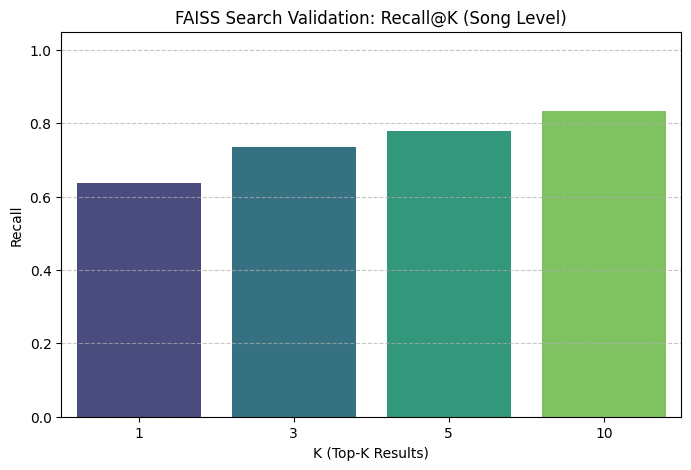

In [21]:
# 6. Plot the Recall@K results
plt.figure(figsize=(8, 5))
sns.barplot(x='K', y='Recall', data=recall_df, palette='viridis')

plt.title('FAISS Search Validation: Recall@K (Song Level)')
plt.xlabel('K (Top-K Results)')
plt.ylabel('Recall')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 5.7 — Baseline Model Comparison
Extracts embeddings using the pre-trained base MERT model (mean-pooling over the last hidden state) 

for the exact same index and query sets to compare Recall@K against the fine-tuned model.

In [22]:
# 1. Load the Base Model
print("Loading base MERT model for comparison...")
base_model = AutoModel.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
base_model.to(DEVICE)
base_model.eval()

def get_baseline_embedding(model, batch_inputs):
    """Standard mean-pooling over the last hidden state for the base model."""
    inputs = {k: v.to(DEVICE) for k, v in batch_inputs.items()}
    outputs = model(**inputs)
    hidden = outputs.last_hidden_state      # (batch, seq_len, 768)
    mean_pooled = hidden.mean(dim=1)        # (batch, 768)
    return F.normalize(mean_pooled, p=2, dim=1)

# 2. Create DataLoaders for the exact same split
train_files = train_df['filename'].tolist()
val_files = val_df['filename'].tolist()

base_train_dataset = AllChunksDataset(train_files, file_lookup, processor, SR)
base_val_dataset   = AllChunksDataset(val_files, file_lookup, processor, SR)

base_train_loader = DataLoader(
    base_train_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_all_chunks, num_workers=2, pin_memory=True
)
base_val_loader = DataLoader(
    base_val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_all_chunks, num_workers=2, pin_memory=True
)

Loading base MERT model for comparison...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

In [23]:
# 3. Extract Baseline Embeddings
base_train_embs_list = []
base_val_embs_list = []

print("Extracting baseline database (index) embeddings...")
with torch.no_grad():
    for fnames, batch_inputs in tqdm(base_train_loader):
        with torch.amp.autocast('cuda', enabled=use_amp):
            embs = get_baseline_embedding(base_model, batch_inputs)
        base_train_embs_list.append(embs.cpu().numpy())

print("\nExtracting baseline validation (query) embeddings...")
with torch.no_grad():
    for fnames, batch_inputs in tqdm(base_val_loader):
        with torch.amp.autocast('cuda', enabled=use_amp):
            embs = get_baseline_embedding(base_model, batch_inputs)
        base_val_embs_list.append(embs.cpu().numpy())

base_train_embs = np.vstack(base_train_embs_list).astype('float32')
base_val_embs = np.vstack(base_val_embs_list).astype('float32')

Extracting baseline database (index) embeddings...


100%|██████████| 4367/4367 [01:15<00:00, 58.16it/s]



Extracting baseline validation (query) embeddings...


100%|██████████| 1092/1092 [00:19<00:00, 56.57it/s]


In [24]:
# 4. Build Baseline FAISS Index & Calculate Recall@K
d_base = 768  # Base MERT hidden size
index_base = faiss.IndexFlatL2(d_base)
index_base.add(base_train_embs)
print(f"\nBaseline FAISS index built. Total vectors: {index_base.ntotal}")

print("\n--- Calculating Baseline Recall@K ---")
D_base_val, I_base_val = index_base.search(base_val_embs, max_k)

base_recall_at_k = {1: 0, 3: 0, 5: 0, 10: 0}

for i in range(len(val_df)):
    query_song = val_df.iloc[i]['filename'].rsplit('_chunk_', 1)[0]

    match_filenames = train_df.iloc[I_base_val[i]]['filename'].values
    match_songs = [f.rsplit('_chunk_', 1)[0] for f in match_filenames]

    for k in base_recall_at_k.keys():
        if query_song in match_songs[:k]:
            base_recall_at_k[k] += 1

base_results_data = []
for k, count in base_recall_at_k.items():
    recall = count / len(val_df)
    base_results_data.append({"K": k, "Recall": recall})
    print(f"Baseline Recall@{k:02d}: {recall:.4f}")

base_recall_df = pd.DataFrame(base_results_data)


Baseline FAISS index built. Total vectors: 34930

--- Calculating Baseline Recall@K ---
Baseline Recall@01: 0.4545
Baseline Recall@03: 0.5557
Baseline Recall@05: 0.6069
Baseline Recall@10: 0.6785


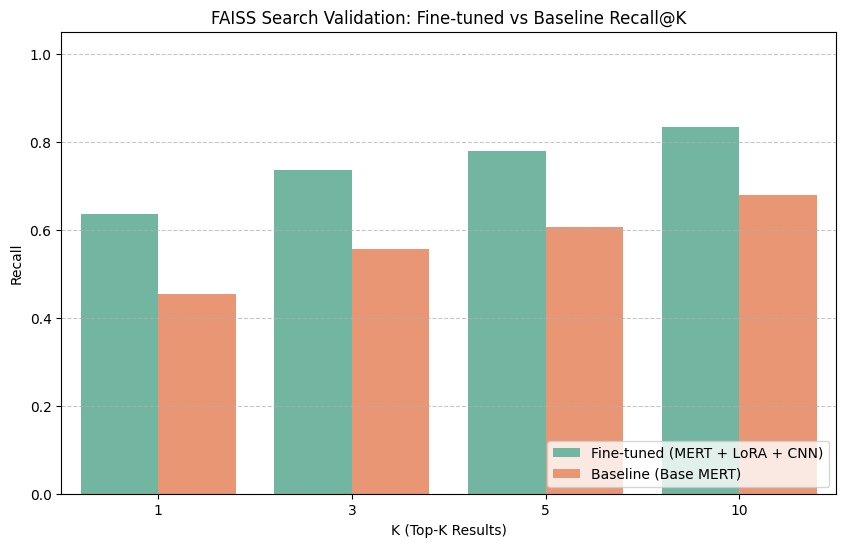

In [25]:
# 5. Plot Comparison
recall_df['Model'] = 'Fine-tuned (MERT + LoRA + CNN)'
base_recall_df['Model'] = 'Baseline (Base MERT)'

combined_recall_df = pd.concat([recall_df, base_recall_df], ignore_index=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='K', y='Recall', hue='Model', data=combined_recall_df, palette='Set2')

plt.title('FAISS Search Validation: Fine-tuned vs Baseline Recall@K')
plt.xlabel('K (Top-K Results)')
plt.ylabel('Recall')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()

In [26]:
# 6. Save Comparison Results to CSV
COMPARISON_CSV = os.path.join(DRIVE_BASE, "results", "recall_comparison.csv")
combined_recall_df.to_csv(COMPARISON_CSV, index=False)
print(f"Comparison results saved to: {COMPARISON_CSV}")
display(combined_recall_df)

Comparison results saved to: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/recall_comparison.csv


,K,Recall,Model
0,1,0.636322,Fine-tuned (MERT + LoRA + CNN)
1,3,0.736288,Fine-tuned (MERT + LoRA + CNN)
2,5,0.779114,Fine-tuned (MERT + LoRA + CNN)
3,10,0.833276,Fine-tuned (MERT + LoRA + CNN)
4,1,0.454483,Baseline (Base MERT)
5,3,0.555708,Baseline (Base MERT)
6,5,0.606893,Baseline (Base MERT)
7,10,0.678461,Baseline (Base MERT)


## 5.8 — Extract Embeddings for Testing Chunks
Extracts 128-dim embeddings for the testing chunks using the fine-tuned model (MERT + LoRA + CNN Head) and saves them to a DataFrame.

In [28]:
# 1. Setup Test Directory and File Lookup
TEST_CHUNK_DIR = "/content/drive/MyDrive/AAI-590 Capstone/capstone_team_3/MidiDatasets/TestingSamples/TestChunks"

test_file_lookup = {}
if os.path.exists(TEST_CHUNK_DIR):
    for root, dirs, files in os.walk(TEST_CHUNK_DIR):
        for f in files:
            if f.endswith(".wav"):
                test_file_lookup[f] = os.path.join(root, f)
else:
    print(f"Directory not found: {TEST_CHUNK_DIR}")

test_files = list(test_file_lookup.keys())
print(f"Found {len(test_files)} test chunks.")

if len(test_files) > 0:
    # 2. Create Dataset and DataLoader
    test_dataset = AllChunksDataset(test_files, test_file_lookup, processor, SR)
    test_loader  = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        collate_fn=collate_all_chunks, num_workers=2, pin_memory=True
    )

    test_results_data = []
    eval_model.eval()
    cnn_head.eval()

    # 3. Extract Embeddings
    with torch.no_grad():
        for fnames, batch_inputs in tqdm(test_loader, desc="Extracting test embeddings"):
            with torch.amp.autocast('cuda', enabled=use_amp):
                embs = get_embedding(eval_model, batch_inputs)
            embs_np = embs.cpu().numpy()

            for fname, emb in zip(fnames, embs_np):
                chunk_match = re.search(r'_chunk_(\d+)\.wav$', fname)
                chunk_num = int(chunk_match.group(1)) if chunk_match else -1
                test_results_data.append({
                    "filename": fname,
                    "chunk": chunk_num,
                    "embeddings": emb
                })

    test_embeddings_df = pd.DataFrame(test_results_data)

    # 4. Save to Pickle
    TEST_EMBEDDINGS_PATH = os.path.join(DRIVE_BASE, "results", "test_embeddings.pkl")
    test_embeddings_df.to_pickle(TEST_EMBEDDINGS_PATH)

    print(f"\nSaved {len(test_embeddings_df)} test embeddings to {TEST_EMBEDDINGS_PATH}")
    display(test_embeddings_df.head())


Found 4116 test chunks.


Extracting test embeddings: 100%|██████████| 515/515 [16:48<00:00,  1.96s/it]


Saved 4116 test embeddings to /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/test_embeddings.pkl


,filename,chunk,embeddings
0,Aragon (Fantasia) Op.47 part 6_chunk_1.wav,1,"[0.08296363, 0.01914027, -0.032113865, 0.10129..."
1,Aragon (Fantasia) Op.47 part 6_chunk_2.wav,2,"[-0.07060223, -0.090025745, -0.06342004, 0.004..."
2,Aragon (Fantasia) Op.47 part 6_chunk_3.wav,3,"[0.040199764, 0.013747733, -0.07446841, -0.000..."
3,Aragon (Fantasia) Op.47 part 6_chunk_4.wav,4,"[0.019444987, -0.042106975, -0.09272113, -0.02..."
4,Aragon (Fantasia) Op.47 part 6_chunk_5.wav,5,"[0.10372586, 0.049052797, -0.026465032, 0.1032..."


# 7. Fine Tuned Model Evaluation on Test Set

## 7.1 — FAISS Search for Testing Chunks
Loads the test embeddings `.pkl` and queries the FAISS index to find the top 10 closest matches from the database for each testing chunk. The output is a formatted DataFrame containing the query file name, the top 1-10 matches, and their similarity scores.

In [29]:
# 1. Load Test Embeddings
TEST_EMBEDDINGS_PATH = os.path.join(DRIVE_BASE, "results", "test_embeddings.pkl")
print(f"Loading test embeddings from: {TEST_EMBEDDINGS_PATH}")
test_df = pd.read_pickle(TEST_EMBEDDINGS_PATH)

# 2. Prepare for FAISS Query
# Convert embeddings to float32 contiguous arrays
test_embs = np.vstack(test_df['embeddings'].values).astype('float32')

# 3. Query the FAISS Index (Top 10)
k_matches = 10
print(f"\nQuerying FAISS index for the top {k_matches} matches...")
D_test, I_test = index.search(test_embs, k_matches)

# 4. Format Results into a DataFrame
search_results = []

for i in range(len(test_df)):
    query_fname = test_df.iloc[i]['filename']
    row_data = {'Query_File': query_fname}

    for rank in range(k_matches):
        match_idx = I_test[i][rank]
        match_fname = train_df.iloc[match_idx]['filename']
        l2_dist = D_test[i][rank]

        # Convert L2 distance to Cosine Similarity (valid for L2-normalized vectors)
        # Formula: Cosine_Similarity = 1 - (L2_Distance^2 / 2)
        # Note: FAISS IndexFlatL2 returns squared L2 distance directly.
        cos_sim = 1.0 - (l2_dist / 2.0)

        row_data[f'Rank_{rank+1}_Match'] = match_fname
        row_data[f'Rank_{rank+1}_Sim'] = round(float(cos_sim), 4)

    search_results.append(row_data)

test_search_results_df = pd.DataFrame(search_results)

# 5. Save and Display Results
TEST_SEARCH_CSV = os.path.join(DRIVE_BASE, "results", "test_search_results.csv")
test_search_results_df.to_csv(TEST_SEARCH_CSV, index=False)

print(f"\nSaved FAISS search results for testing chunks to: {TEST_SEARCH_CSV}")
display(test_search_results_df.head())

Loading test embeddings from: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/test_embeddings.pkl

Querying FAISS index for the top 10 matches...

Saved FAISS search results for testing chunks to: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/test_search_results.csv


,Query_File,Rank_1_Match,Rank_1_Sim,Rank_2_Match,Rank_2_Sim,Rank_3_Match,Rank_3_Sim,Rank_4_Match,Rank_4_Sim,Rank_5_Match,...,Rank_6_Match,Rank_6_Sim,Rank_7_Match,Rank_7_Sim,Rank_8_Match,Rank_8_Sim,Rank_9_Match,Rank_9_Sim,Rank_10_Match,Rank_10_Sim
0,Aragon (Fantasia) Op.47 part 6_chunk_1.wav,alb_se6_chunk_41.wav,0.9710,alb_se6_chunk_6.wav,0.9618,alb_se6_chunk_39.wav,0.9608,alb_se6_chunk_40.wav,0.9581,schub_d960_1_chunk_523.wav,...,ty_april_chunk_51.wav,0.9481,beethoven_opus90_1_chunk_85.wav,0.9451,ty_april_chunk_50.wav,0.9432,bach_846_chunk_60.wav,0.9429,ty_april_chunk_28.wav,0.9419
1,Aragon (Fantasia) Op.47 part 6_chunk_2.wav,liz_rhap12_chunk_119.wav,0.8454,waldstein_1_chunk_221.wav,0.8066,liz_rhap12_chunk_115.wav,0.8057,liz_rhap12_chunk_118.wav,0.8048,liz_rhap12_chunk_117.wav,...,schubert_D850_1_chunk_301.wav,0.7968,liz_donjuan_chunk_450.wav,0.7881,waldstein_1_chunk_99.wav,0.7777,alb_se6_chunk_13.wav,0.7760,liz_rhap12_chunk_114.wav,0.7720
2,Aragon (Fantasia) Op.47 part 6_chunk_3.wav,alb_se6_chunk_23.wav,0.9397,muss_8_chunk_138.wav,0.9375,brahms_opus1_4_chunk_298.wav,0.9273,schubert_D935_4_chunk_207.wav,0.9262,muss_8_chunk_25.wav,...,schubert_D850_4_chunk_101.wav,0.9223,chpn_op25_e3_chunk_17.wav,0.9194,alb_se6_chunk_15.wav,0.9188,schuim-1_chunk_220.wav,0.9181,beethoven_opus10_1_chunk_155.wav,0.9165
3,Aragon (Fantasia) Op.47 part 6_chunk_4.wav,alb_se6_chunk_23.wav,0.9230,chpn-p12_chunk_12.wav,0.9137,grieg_march_chunk_17.wav,0.9121,grieg_march_chunk_18.wav,0.9041,alb_se6_chunk_22.wav,...,grieg_wedding_chunk_163.wav,0.9000,alb_se6_chunk_15.wav,0.8999,beethoven_opus10_1_chunk_155.wav,0.8990,schuim-1_chunk_220.wav,0.8969,grieg_wedding_chunk_35.wav,0.8942
4,Aragon (Fantasia) Op.47 part 6_chunk_5.wav,alb_se6_chunk_41.wav,0.9526,haydn_9_2_chunk_70.wav,0.9474,ty_april_chunk_28.wav,0.9467,ty_april_chunk_46.wav,0.9440,ty_april_chunk_29.wav,...,ty_april_chunk_47.wav,0.9420,ty_april_chunk_27.wav,0.9418,ty_april_chunk_51.wav,0.9397,ty_april_chunk_48.wav,0.9385,alb_se6_chunk_6.wav,0.9379


## 7.2 — Test Set Recall Calculation
Calculates Recall@1, 3, 5, and 10 for the test chunks using the ground truth mapping from `TestingReferences.csv`.

In [34]:
# 1. Load the ground truth references
REF_CSV = '/content/TestingReferences.csv'
print(f"Loading references from: {REF_CSV}")
ref_df = pd.read_csv(REF_CSV)
display(ref_df.head())

# Use 'FileName' as query and 'OriginalFileName' as ground truth.
col_query = 'FileName'
col_truth = 'OriginalFileName'
print(f"\nUsing '{col_query}' as query and '{col_truth}' as ground truth.\n")

# Clean extensions from truth mapping keys and values
truth_mapping = {}
for q, t in zip(ref_df[col_query], ref_df[col_truth]):
    if pd.isna(q) or pd.isna(t): continue
    clean_q = str(q).rsplit('.', 1)[0]
    clean_t = str(t).rsplit('.', 1)[0]
    truth_mapping[clean_q] = clean_t

# 2. Calculate Recall@K
recall_at_k = {1: 0, 3: 0, 5: 0, 10: 0}
total_evaluated = 0

# Assuming test_search_results_df is in memory from Section 9.
# If not, load it: test_search_results_df = pd.read_csv(TEST_SEARCH_CSV)
for _, row in test_search_results_df.iterrows():
    query_file = row['Query_File']

    # Strip '_chunk_...' to match the cleaned truth_mapping keys
    base_query = query_file.rsplit('_chunk_', 1)[0]

    if base_query not in truth_mapping:
        continue

    true_song = truth_mapping[base_query]
    total_evaluated += 1

    # Extract predicted song names from the top 10 matches
    predicted_songs = []
    for rank in range(1, 11):
        match_file = row[f'Rank_{rank}_Match']
        # Strip the chunk suffix to get the base song name
        pred_song = match_file.rsplit('_chunk_', 1)[0]
        predicted_songs.append(pred_song)

    # Check for hits at different K values
    for k in recall_at_k.keys():
        if true_song in predicted_songs[:k]:
            recall_at_k[k] += 1

# 3. Display the final results
print(f"Total valid queries evaluated: {total_evaluated}")
results_data = []
for k, hits in recall_at_k.items():
    recall = hits / total_evaluated if total_evaluated > 0 else 0
    results_data.append({"K": k, "Recall": recall})
    print(f"Recall@{k:02d}: {recall:.4f}")

test_recall_df = pd.DataFrame(results_data)
display(test_recall_df)


Loading references from: /content/TestingReferences.csv


,FileName,FullTestPath,OriginalFileName
0,FurElise_Intro-2ndVers_K-Amin_T-70_bothhands.wav,audio/Beethoven/FurElise_Intro-2ndVers_K-Amin_...,elise.mid
1,FurElise_Intro_K-Amaj_T-138_bothhands_swing.wav,audio/Beethoven/FurElise_Intro_K-Amaj_T-138_bo...,elise.mid
2,FurElise_Intro_K-Amaj_T-138_righthand_swing.wav,audio/Beethoven/FurElise_Intro_K-Amaj_T-138_ri...,elise.mid
3,FurElise_Intro_K-Amaj_T-70_righthand.wav,audio/Beethoven/FurElise_Intro_K-Amaj_T-70_rig...,elise.mid
4,FurElise_Intro_K-Cmin_T-65_righthand.wav,audio/Beethoven/FurElise_Intro_K-Cmin_T-65_rig...,elise.mid



Using 'FileName' as query and 'OriginalFileName' as ground truth.

Total valid queries evaluated: 4116
Recall@01: 0.0794
Recall@03: 0.1412
Recall@05: 0.1781
Recall@10: 0.2512


,K,Recall
0,1,0.079446
1,3,0.141156
2,5,0.178086
3,10,0.251215


## 7.3 — Save Detailed Match Results
Combines the FAISS search results with the extracted chunk numbers and original ground truth names, then saves to a CSV.

In [36]:
# Track retrieval results per chunk
detailed_results = []

for _, row in test_search_results_df.iterrows():
    query_file = row['Query_File']

    # Extract base query and chunk number
    base_query = query_file.rsplit('_chunk_', 1)[0]
    chunk_match = re.search(r'_chunk_(\d+)\.wav$', query_file)
    chunk_num = int(chunk_match.group(1)) if chunk_match else -1

    # Get original ground truth name
    original_name = truth_mapping.get(base_query, "Unknown")

    # Build the row dictionary
    row_data = {
        'Test_File_Name': query_file,
        'Chunk_Number': chunk_num,
        'Original_Name': original_name
    }

    # Add top 1-10 matches from the FAISS results, stripping the chunk suffix
    for rank in range(1, 11):
        match_file = row[f'Rank_{rank}_Match']
        pred_song = match_file.rsplit('_chunk_', 1)[0] if isinstance(match_file, str) else match_file
        row_data[f'Top_{rank}_Match'] = pred_song
        row_data[f'Top_{rank}_Sim'] = row[f'Rank_{rank}_Sim']

    detailed_results.append(row_data)

detailed_df = pd.DataFrame(detailed_results)

# Save to Drive
DETAILED_CSV_PATH = os.path.join(DRIVE_BASE, "results", "test_detailed_matches.csv")
detailed_df.to_csv(DETAILED_CSV_PATH, index=False)

print(f"Saved {len(detailed_df)} detailed matches to: {DETAILED_CSV_PATH}")
display(detailed_df.head())


Saved 4116 detailed matches to: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/test_detailed_matches.csv


,Test_File_Name,Chunk_Number,Original_Name,Top_1_Match,Top_1_Sim,Top_2_Match,Top_2_Sim,Top_3_Match,Top_3_Sim,Top_4_Match,...,Top_6_Match,Top_6_Sim,Top_7_Match,Top_7_Sim,Top_8_Match,Top_8_Sim,Top_9_Match,Top_9_Sim,Top_10_Match,Top_10_Sim
0,Aragon (Fantasia) Op.47 part 6_chunk_1.wav,1,alb_se6,alb_se6,0.9710,alb_se6,0.9618,alb_se6,0.9608,alb_se6,...,ty_april,0.9481,beethoven_opus90_1,0.9451,ty_april,0.9432,bach_846,0.9429,ty_april,0.9419
1,Aragon (Fantasia) Op.47 part 6_chunk_2.wav,2,alb_se6,liz_rhap12,0.8454,waldstein_1,0.8066,liz_rhap12,0.8057,liz_rhap12,...,schubert_D850_1,0.7968,liz_donjuan,0.7881,waldstein_1,0.7777,alb_se6,0.7760,liz_rhap12,0.7720
2,Aragon (Fantasia) Op.47 part 6_chunk_3.wav,3,alb_se6,alb_se6,0.9397,muss_8,0.9375,brahms_opus1_4,0.9273,schubert_D935_4,...,schubert_D850_4,0.9223,chpn_op25_e3,0.9194,alb_se6,0.9188,schuim-1,0.9181,beethoven_opus10_1,0.9165
3,Aragon (Fantasia) Op.47 part 6_chunk_4.wav,4,alb_se6,alb_se6,0.9230,chpn-p12,0.9137,grieg_march,0.9121,grieg_march,...,grieg_wedding,0.9000,alb_se6,0.8999,beethoven_opus10_1,0.8990,schuim-1,0.8969,grieg_wedding,0.8942
4,Aragon (Fantasia) Op.47 part 6_chunk_5.wav,5,alb_se6,alb_se6,0.9526,haydn_9_2,0.9474,ty_april,0.9467,ty_april,...,ty_april,0.9420,ty_april,0.9418,ty_april,0.9397,ty_april,0.9385,alb_se6,0.9379


## 7.4 — Final Recall Calculation (Cleaned Names)
Calculates the final Recall metrics directly from the cleaned base names in the detailed matches dataframe.

In [37]:
# Calculate Recall@K from the cleaned detailed_df
recall_at_k = {1: 0, 3: 0, 5: 0, 10: 0}
total_evaluated = len(detailed_df)

for _, row in detailed_df.iterrows():
    true_song = row['Original_Name']

    # Skip if ground truth mapping was not found
    if true_song == "Unknown":
        total_evaluated -= 1
        continue

    # Extract top 10 predicted base song names
    predicted_songs = [row[f'Top_{rank}_Match'] for rank in range(1, 11)]

    # Check for hits at different K values
    for k in recall_at_k.keys():
        if true_song in predicted_songs[:k]:
            recall_at_k[k] += 1

print(f"Total valid queries evaluated: {total_evaluated}")
final_results_data = []
for k, hits in recall_at_k.items():
    recall = hits / total_evaluated if total_evaluated > 0 else 0
    final_results_data.append({"K": k, "Recall": recall})
    print(f"Recall@{k:02d}: {recall:.4f}")

final_recall_df = pd.DataFrame(final_results_data)
display(final_recall_df)

Total valid queries evaluated: 4116
Recall@01: 0.0794
Recall@03: 0.1412
Recall@05: 0.1781
Recall@10: 0.2512


,K,Recall
0,1,0.079446
1,3,0.141156
2,5,0.178086
3,10,0.251215


## 7.5 — Error Analysis (Missed at Rank 1)
Analyzing cases where the correct song was not the top prediction to

understand common confusions and whether the correct song was still nearby in the Top 5.

Total queries missed at Rank 1: 3789 out of 4116
Caught in Ranks 2-5: 406 (10.72%)

--- Top 10 Most Common Confusions (True -> Predicted) ---
21 times: mz_331_1 -> liz_donjuan
21 times: mz_331_1 -> chpn_op33_2
20 times: alb_esp6 -> alb_se5
19 times: mz_311_1 -> schubert_D850_4
18 times: mz_331_1 -> schubert_D850_1
17 times: beethoven_hammerklavier_1 -> beethoven_hammerklavier_3
14 times: mz_331_1 -> mz_331_3
14 times: mz_333_1 -> schub_d960_4
13 times: mz_331_1 -> chpn_op7_2
12 times: mond_1 -> schuim-4


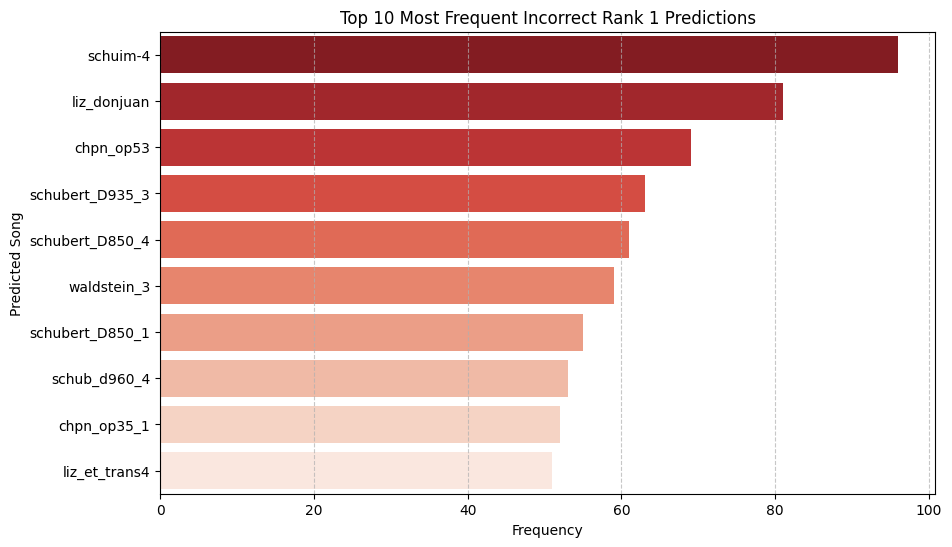

In [39]:
# Filter for valid queries where Rank 1 was incorrect
missed_rank1_df = detailed_df[(detailed_df['Original_Name'] != 'Unknown') &
                              (detailed_df['Original_Name'] != detailed_df['Top_1_Match'])]

print(f"Total queries missed at Rank 1: {len(missed_rank1_df)} out of {total_evaluated}")

# 1. Did it appear in Top 2-5?
caught_in_top5 = 0
for _, row in missed_rank1_df.iterrows():
    true_song = row['Original_Name']
    predicted_2_to_5 = [row[f'Top_{rank}_Match'] for rank in range(2, 6)]
    if true_song in predicted_2_to_5:
        caught_in_top5 += 1

print(f"Caught in Ranks 2-5: {caught_in_top5} ({caught_in_top5/len(missed_rank1_df):.2%})")

# 2. Most common confusions (True Song -> Incorrect Rank 1 Prediction)
confusions = missed_rank1_df.apply(lambda row: f"{row['Original_Name']} -> {row['Top_1_Match']}", axis=1)
top_confusions = Counter(confusions).most_common(10)

print("\n--- Top 10 Most Common Confusions (True -> Predicted) ---")
for conf, count in top_confusions:
    print(f"{count} times: {conf}")

# 3. What is the model predicting most often when it's wrong?
top_wrong_predictions = missed_rank1_df['Top_1_Match'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_wrong_predictions.values, y=top_wrong_predictions.index, hue=top_wrong_predictions.index, palette='Reds_r', legend=False)
plt.title('Top 10 Most Frequent Incorrect Rank 1 Predictions')
plt.xlabel('Frequency')
plt.ylabel('Predicted Song')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


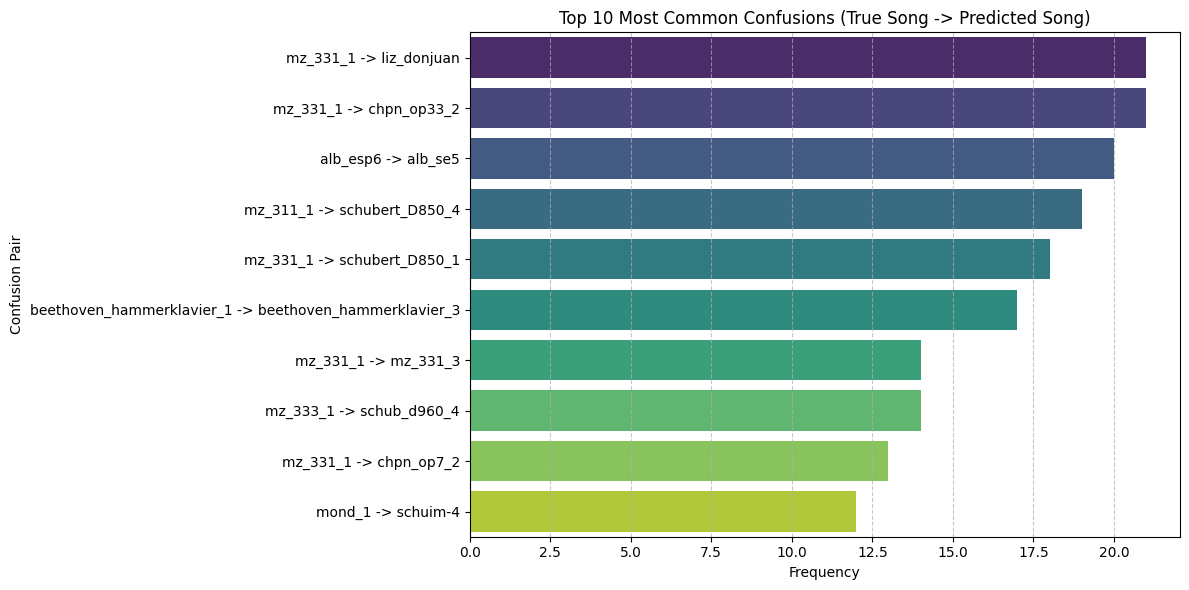

In [40]:
# Extract labels and counts from top_confusions
conf_labels = [conf for conf, count in top_confusions]
conf_counts = [count for conf, count in top_confusions]

plt.figure(figsize=(12, 6))
sns.barplot(x=conf_counts, y=conf_labels, hue=conf_labels, palette='viridis', legend=False)
plt.title('Top 10 Most Common Confusions (True Song -> Predicted Song)')
plt.xlabel('Frequency')
plt.ylabel('Confusion Pair')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()